<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/blog-202503/vanishing-and-exploding-gradients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualising Vanishing and Exploding Gradients

Vanishing gradients used to be a problem in the past when most models used the Sigmoid activation function. This was inspired by observation of biological neurons. It worked acceptibly for small numbers of layers (eg: 1 hidden layer), but community progress stalled until everyone switched to the use of ReLU.

Today, vanishing gradients are much less of a problem. But they can still be a problem in certain situations. For example, vanishing gradients cause problems with the training of RNNs which still tend to make use of smooth non-linear functions like sigmoid and tanh. And they are likely to become more of problem as people begin to experiment with more novel architectures - something that has been happening a lot since the advent of Transformer networks.

Thus, it's good to have some tools up your sleeve to monitor for vanishing gradients and to investigate them.

**Preliminaries**

This notebook follows a "guide" style, but it assumes that you have some familiarity with the `training-instrumentation-toolkit`. Please see the notebooks in the following github location for an introduction:
* https://github.com/malcolmlett/training-instrumentation-toolkit/blob/main/doc/index.md

Except where state otherwise, the results below were achieved while running the notebook in Google Colab with only a CPU.

**Blog Post**

This notebook for prepared for a Mar 2025 blog post. Link coming...

**Acknowledgements**

The example problems below take inspiration from other blogs:

* https://machinelearningmastery.com/visualizing-the-vanishing-gradient-problem/
* https://github.com/ayulockin/debugNNwithWandB/blob/master/Pytorch_wandb_Exploding_Gradient_NaN.ipynb


In [166]:
# Install Training Instrumentation Toolkit
# (locked to specific git revision so this notebook always works)
import os
import sys
if not os.path.isdir('training-instrumentation-toolkit'):
  !git clone https://github.com/malcolmlett/training-instrumentation-toolkit.git
  !cd training-instrumentation-toolkit && git checkout 4c46b9f
sys.path.append('training-instrumentation-toolkit')

# Imports
import train_instrumentation as tinstr
import train_explainer as texpl
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import matplotlib.ticker as mticker
import sklearn

Cloning into 'training-instrumentation-toolkit'...
remote: Enumerating objects: 1395, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 1395 (delta 86), reused 55 (delta 25), pack-reused 1239 (from 1)
Receiving objects: 100% (1395/1395), 107.55 MiB | 23.17 MiB/s, done.
Resolving deltas: 100% (835/835), done.
Note: switching to '4c46b9f'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 4c46b9f Bug fix for time-tracking when running with `tf.con

## Dataset
The dataset: the classic "make_circles" data from SciKit Learn.

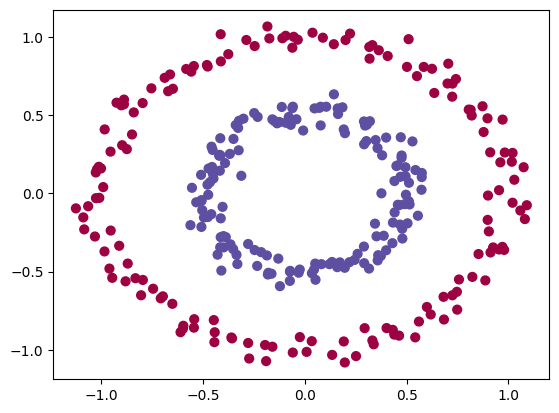

In [66]:
def binary_classification_dataset():
  np.random.seed(1)
  train_X, train_Y = sklearn.datasets.make_circles(n_samples=300, factor=0.5, noise=.05)
  train_X = train_X
  train_Y = train_Y.reshape((-1, 1))
  return train_X, train_Y

train_X, train_Y = binary_classification_dataset()
plt.scatter(train_X[:, 0], train_X[:, 1], c=train_Y, s=40, cmap=plt.cm.Spectral);
plt.show()

## Model
We'll be trying a few different models but all following a basic outline of a number of dense layers ending with a single sigmoid unit for binary classification.

So it'll he helpful to have a factory method for creating these quickly...

In [111]:
def binary_classification_model(activation, initializer, hidden_units=5, hidden_layers=4):
  """
  For example, model("relu", "he_normal") is equivalent to:
    return tf.keras.Sequential([
        layers.Input(shape=(2,), name="input"),
        layers.Dense(5, activation="relu", kernel_initializer="he_normal", name="dense1"),
        layers.Dense(5, activation="relu", kernel_initializer="he_normal", name="dense2"),
        layers.Dense(5, activation="relu", kernel_initializer="he_normal", name="dense3"),
        layers.Dense(5, activation="relu", kernel_initializer="he_normal", name="dense4"),
        layers.Dense(1, activation="sigmoid", kernel_initializer="he_normal", name="class")
    ])
  """
  return tf.keras.Sequential([
      tf.keras.layers.Input(shape=(2,), name="input"),
      *[tf.keras.layers.Dense(hidden_units, activation=activation, kernel_initializer=initializer, name=f"dense{i+1}") for i in range(hidden_layers)],
      tf.keras.layers.Dense(1, activation="sigmoid", kernel_initializer=initializer, name="class")
  ])

## Vanishing Gradients with Sigmoid Activation Functions
Vanishing gradients used to be a problem in the past when sigmoid activation functions were popular. Thus, as is common on the topic of vanishing gradients, I'll revert back to a sigmoid activation function in order to demonstrate the problem.

I'm also going to run this training experiment instrumented with the "4 main callbacks" provided by the toolkit, which respectively collect:
* variables - the weights and biases
* gradients - the gradients of the weights and biases
* outputs - the layer outputs
* output gradients - the gradients w.r.t. to the layer outputs, and used during backprop to calculate the gradients for the weights and biases

Note that to be fair on the use of sigmoid, we'll use the Glorot initialization scheme, which was devised for the use of sigmoid, whereas the He initialization scheme was designed for ReLU.

In [78]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = binary_classification_model('sigmoid', 'glorot_uniform')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = tinstr.fit(model, train_X, train_Y, batch_size=32, epochs=100, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), tinstr.HistoryStats(), variables, gradients, outputs, output_gradients])

Epoch    10 - 798.65ms/epoch: accuracy: 0.5000  loss: 0.6944  
Epoch    20 - 290.10ms/epoch: accuracy: 0.5000  loss: 0.6933  
Epoch    30 - 307.98ms/epoch: accuracy: 0.4867  loss: 0.6932  
Epoch    40 - 269.54ms/epoch: accuracy: 0.5000  loss: 0.6933  
Epoch    50 - 280.16ms/epoch: accuracy: 0.5000  loss: 0.6932  
Epoch    60 - 280.70ms/epoch: accuracy: 0.4800  loss: 0.6932  
Epoch    70 - 294.05ms/epoch: accuracy: 0.4567  loss: 0.6932  
Epoch    80 - 282.88ms/epoch: accuracy: 0.5000  loss: 0.6933  
Epoch    90 - 256.73ms/epoch: accuracy: 0.5000  loss: 0.6932  
Epoch   100 - 257.41ms/epoch: accuracy: 0.4733  loss: 0.6932  


The toolkit includes an out-of-box method for plotting the results from the training history. The `HistoryStats` callback collects the percentile distribution of loss over the course of the epoch, and the toolkit's history plotting function makes that easy to display:

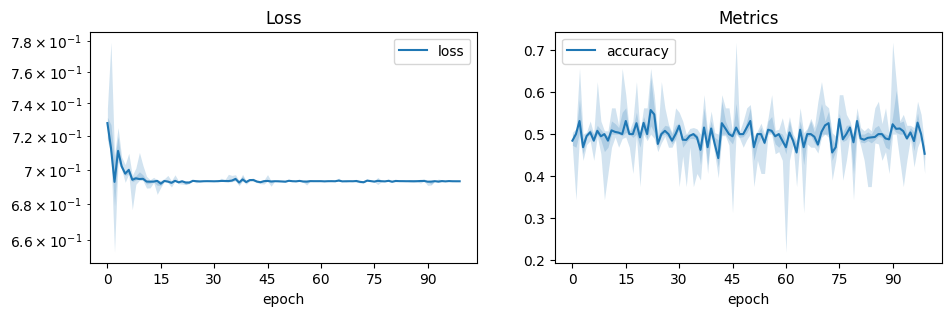

In [79]:
tinstr.plot_train_history(history)

But more than that, the toolkit will plot a "single pain of glass" summary of all the important information from the history callback plus the "4 main callbacks":

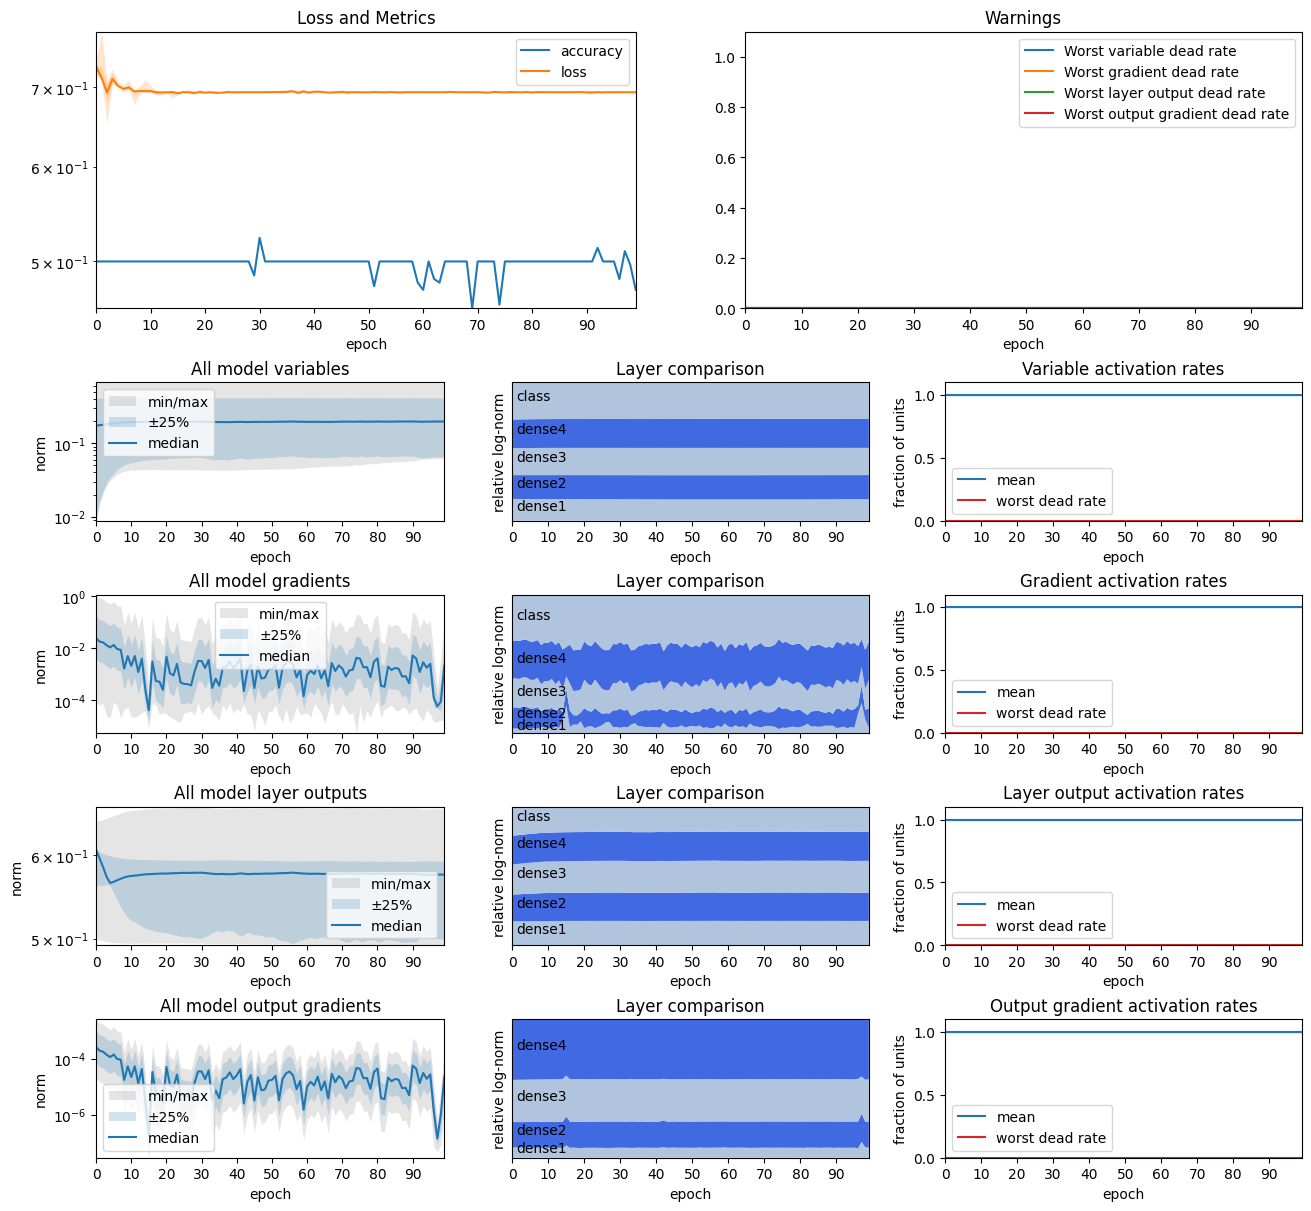

In [80]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

**Commentary**

In the case of vanishing gradients, what we're checking for is whether the magnitude of the losses are approximately consistent through the layers, or whether the losses are significantly attenuated by the time they flow from final layer to first layer.

Take particular note of the "Layer Comparison" chart for the gradients. It pulls out just the weights of each layer (ie: ignores bias) and plots the _relative log norms_ of the gradients for those weights. The thinnest horizontal swimline can be considered as "1 unit" and any that appear some multiplies in size larger are in actual fact that many _orders of magnitude_ larger.

These plots are designed to expose information needed to answer many different kinds of questions, the presence or not of a vanishing gradient problem isn't quite so obvious.

We can also drill down deeper and look at the gradients of individual layers...


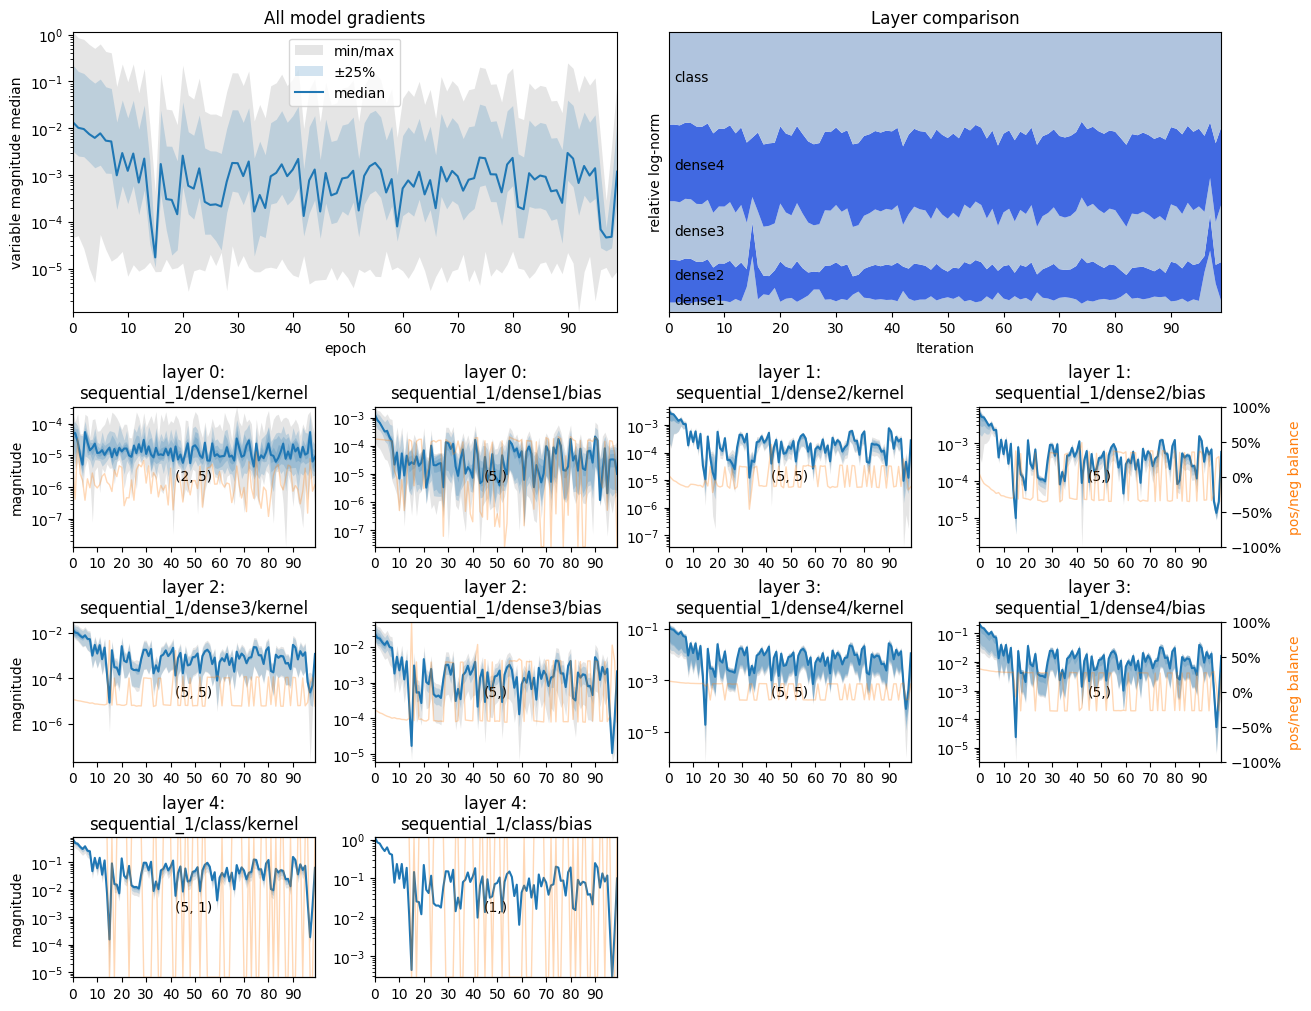

In [81]:
tinstr.plot_value_history(gradients)

**Commentary**

If you examine the scales of each layer's chart you'll see that there's clearly a problem here. The earliest layers hover around $10^{-4}$ while the later layers hover between $10^{-2}$ to $10^{-1}$.

To make this even more obvious, we could create our own plots. Thankfully, the data is all available and easy for us to pull out. So we'll do just that.

A common strategy is to plot the mean and stddev of the gradients. In practice, gradients usually follow a pseudo-normal curve with a very sharp/narrow middle very close to zero, and approximately balanced long tails into both the positive and negative regions:

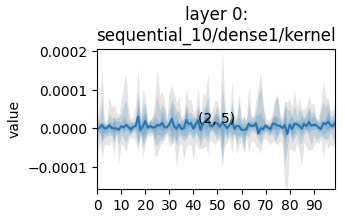

The mean fails to convey much information.

There are two options that I prefer:
* mean or median of absolute magnitude
* L2-norm, aka "euclidean norm", normalized by the size of the tensor

The first is closely related to both the stddev of the raw values and to the L1-norm, and gives a linear and equal _weighting_ to all values. The second is very popular in academic literature because it naturally produces a scalar value that can be plotted easily. However, it applies a non-linear and non-equal weighting to the values, amplifying larger values more than smaller values. This is good for an error metric or loss function, but not so good when you want to get a feel for the magnitude of the gradients. When using the L2-norm, I also prefer to normalize it by the size of the tensor, effectively computing the RMS of the values, so that the scale of the norm is not affected by differences in the number of units in each layer.

The callbacks collect percentile stats on the raw values and the magnitude values, and they compute and collect the (normalized) norms. For comparison, let's first calculate and plot a few things...

In [82]:
def layer_idx_to_variable_idx(model, layer_index):
  """
  The callbacks collect data on variables, and index by variables as returned by model.variables.
  Additionally, each layer has potentially multiple variables (eg: weights + biases).
  Here we map the layer index to the variable index of the first variable in the layer -- usually the "main" weights tensor.
  """
  mapping = tinstr.variable_indices_by_layer(model)
  return mapping[layer_index][0] if mapping[layer_index] else None

def pull_out(gradients_cb, reduction):
  """
  Little bit of data manipulation to pull out the data we want.
  Returns:
    np-array of shape (epochs, layers)
  """
  data = []
  for l_idx, layer in enumerate(gradients_cb.model.layers):
    var_idx = layer_idx_to_variable_idx(gradients_cb.model, l_idx)
    if var_idx is not None:
      if reduction == "value-mean":
        # estimate by averaging over all raw value percentiles
        layer_data = np.mean(gradients_cb.value_stats[var_idx].to_numpy(), axis=-1)  # shape: (epochs,)
      elif reduction == "value-stddev":
        # approximate via geometric mean over the magnitude percentiles
        # (with a little epsilon to avoid log(0) issues)
        layer_data = gradients_cb.magnitude_stats[var_idx].to_numpy()
        layer_data = np.exp(np.mean(np.log(layer_data + 1e-9), axis=-1))
      elif reduction == "mag-median":
        # take 50th-percentile of magnitude stats
        layer_data = gradients_cb.magnitude_stats[var_idx][50].to_numpy()  # shape: (epochs,)
      elif reduction == "norm":
        layer_data = gradients_cb.value_norms[var_idx]  # shape: (epochs,)
      else:
        raise ValueError(f"Unknown reduction: {reduction}")
      data.append(layer_data)
  return np.array(data).T  # shape: (epochs, layers)

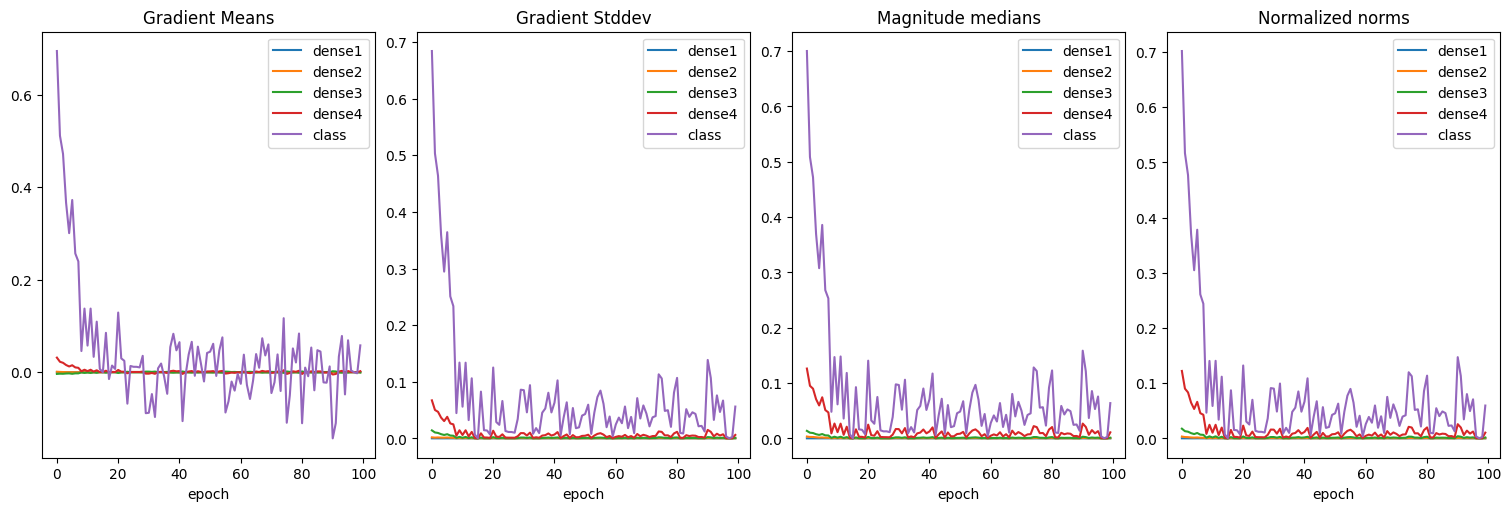

In [83]:
plt.figure(figsize=(15,5), layout='constrained')
layer_names = [layer.name for layer in model.layers]

# estimated mean - average over all percentiles on raw values
plt.subplot(1,4,1)
plt.title("Gradient Means")
plt.plot(pull_out(gradients, "value-mean"), label=layer_names)
plt.xlabel("epoch")
plt.legend()

# estimated stddev - geometric average over all percentiles on magnitude values
plt.subplot(1,4,2)
plt.title("Gradient Stddev")
plt.plot(pull_out(gradients, "value-stddev"), label=layer_names)
plt.xlabel("epoch")
plt.legend()

# median of magnitude stats
plt.subplot(1,4,3)
plt.title("Magnitude medians")
plt.plot(pull_out(gradients, "mag-median"), label=layer_names)
plt.xlabel("epoch")
plt.legend()

# norms
plt.subplot(1,4,4)
plt.title("Normalized norms")
plt.plot(pull_out(gradients, "norm"), label=layer_names)
plt.xlabel("epoch")
plt.legend()

plt.show()

**Commentary**

It's hard to see, but the overall scale of the means is considerably less than both than the magnitude medians and norms. Also, the means expose us to the sign of the gradients in a way that isn't helpful for this particular analysis.

The vanishing gradient problems is also evident, but it can be hard to interpret on first glance with the effects of noise and the radically reducing scales as training progresses.

A different way of plotting this is to put the layers along the bottom axis, with a separate series for each epoch. To make that intelligeble while also being able to see the trend over time, we'll pick out just a few epochs rather than show the whole lot. Lastly, I'm curious to see how the different ways of measuring gradient scale compare to each other, so I'll continue to plot all the but means.

In [86]:
def plot_layer_magnitudes(gradients_cb, num_epoch_samples=5):
  selected_epochs = np.floor(np.linspace(0, gradients.params['epochs']-1, num_epoch_samples)).astype(int)
  plt.figure(figsize=(15,5), layout='constrained')

  plt.subplot(1,3,1)
  plt.title('Layer gradients')
  data = pull_out(gradients_cb, 'value-stddev')
  for epoch in selected_epochs:
    plt.plot(data[epoch, :], label=f"epoch {epoch}")
  plt.xlabel('trainable layer')
  plt.ylabel('gradient stddev (estimated)')
  plt.legend()
  plt.yscale('log')
  plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

  plt.subplot(1,3,2)
  plt.title('Layer gradients')
  data = pull_out(gradients_cb, 'mag-median')
  for epoch in selected_epochs:
    plt.plot(data[epoch, :], label=f"epoch {epoch}")
  plt.xlabel('trainable layer')
  plt.ylabel('magnitude median')
  plt.legend()
  plt.yscale('log')
  plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

  plt.subplot(1,3,3)
  plt.title('Layer gradients')
  data = pull_out(gradients_cb, 'norm')
  for epoch in selected_epochs:
    plt.plot(data[epoch, :], label=f"epoch {epoch}")
  plt.xlabel('trainable layer')
  plt.ylabel('norm')
  plt.legend()
  plt.yscale('log')
  plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

  plt.show()

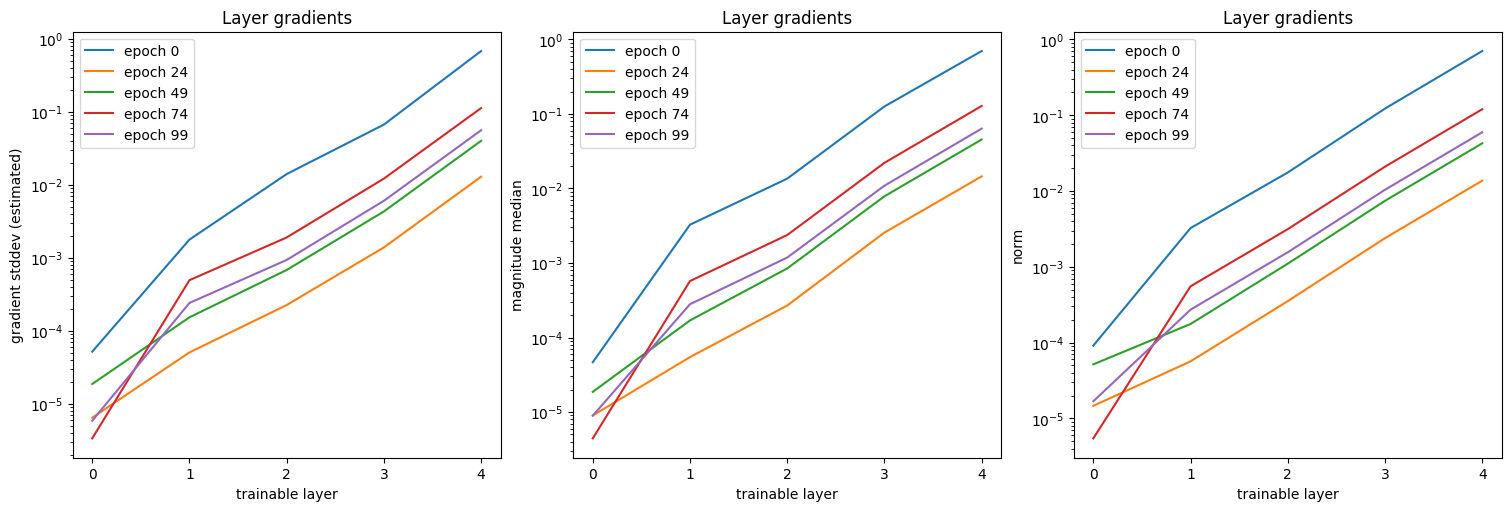

In [87]:
plot_layer_magnitudes(gradients)

**Commentary**

Now the issue is clear.

From the first epoch to the last, the gradients get considerably attenuated as they backprop from the last layer towards the first.

The solution in this case is to use ReLU instead of sigmoid, but that's not the point.

The point is this: you need ways to track and visualise how well your model is training. When training doesn't progress as well as you'd expect, you want to have the tools available to quickly and easily identify the problem. And when training progress appears to be working, you want to know early when there are subtle issues that are affecting things in a less obvious way.

So use these techniques to keep an eye on your models.

## Oscillations

Before we move off from our Sigmoid network, there is another thing for worth noticing and briefly discussing - the shark-tooth shape of the median gradients. That's a possible indication of oscillating gradients, and they're also a problem for training. There's a detailed discussion of oscillations in another notebook within this series, so I won't go into much discussion here. Just briefly though let's take a quick look...

Log plots are great for comparing data across different scales, but they necessite the use of absolute magnitudes rather than original values because log plots can't represent negative values. The plot above includes a faint orange line that tries to make up for that by superimposing an indication of the the "sign balance" across the values. 0% means that it's perfectly balanced, +100% means that all data points are positive, and -100% means that all data points are negative. The orange line seems to indicate that there's some sign variation, particularly badly in the last layer.

We can see this more clearly if we plot the distributions over the raw values...

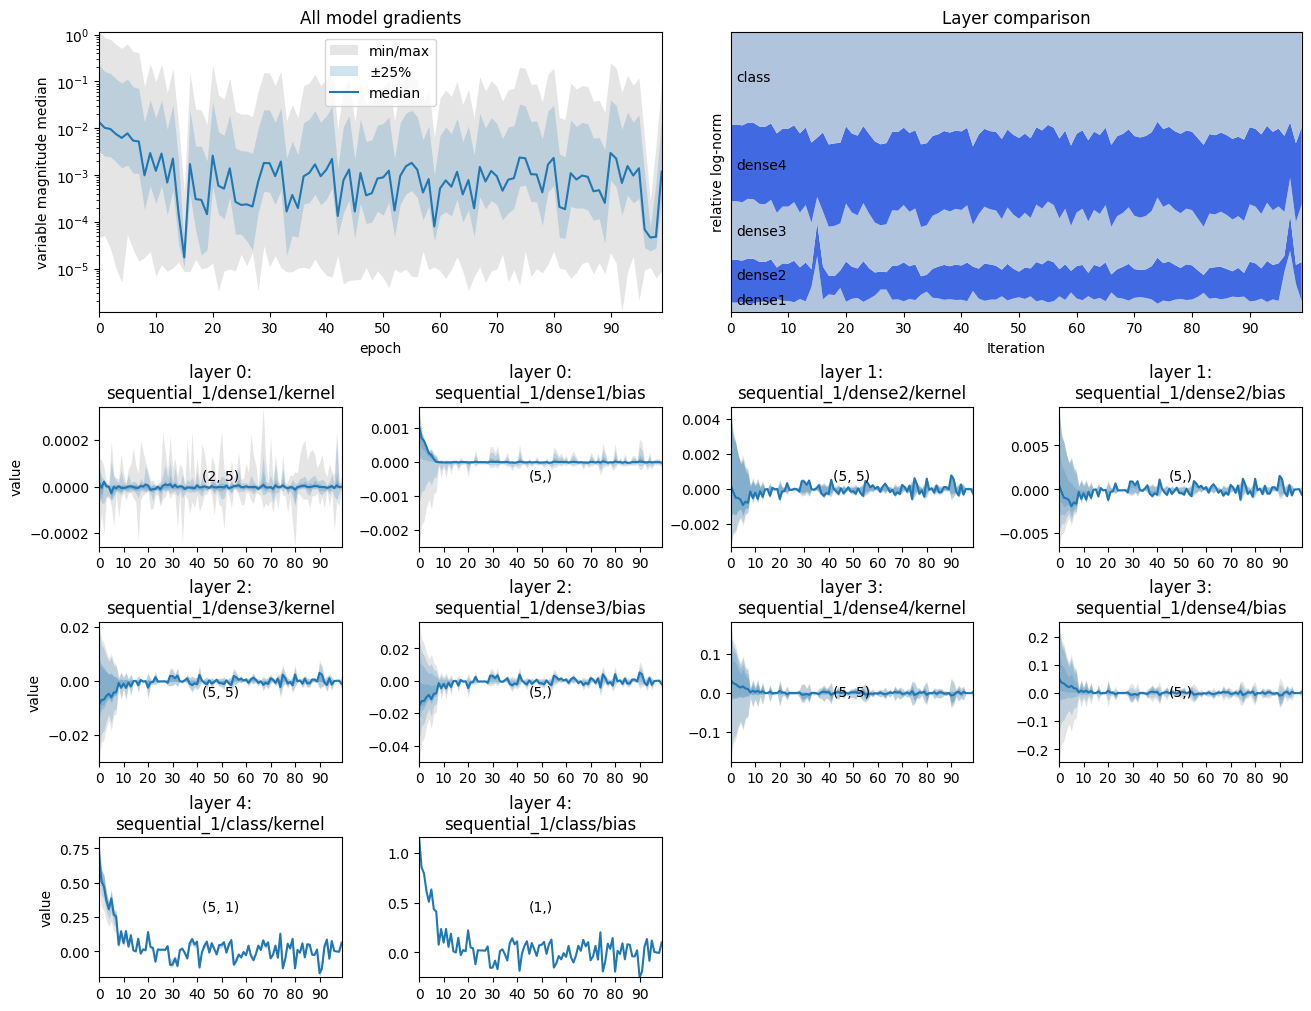

In [88]:
tinstr.plot_value_history(gradients, show='values')

## Solving Vanishing Gradients with ReLU Activation
In general, the advice for vanishing gradients is to use the ReLU activation functions. But vanishing gradients can still sometimes happen with ReLU. We've identified above a clear-cut case of vanishing gradients, but they won't always be so obvious.

Thus, it will be useful to have an idea of what a "well behaved" model looks like.

So let's run the same training but this time using ReLU. Accordingly, we'll
also switch to He normalization.




In [89]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = binary_classification_model('relu', 'he_normal')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = tinstr.fit(model, train_X, train_Y, batch_size=32, epochs=100, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), tinstr.HistoryStats(), variables, gradients, outputs, output_gradients])

Epoch    10 - 759.13ms/epoch: accuracy: 0.5467  loss: 0.6497  
Epoch    20 - 301.43ms/epoch: accuracy: 0.6467  loss: 0.6070  
Epoch    30 - 267.98ms/epoch: accuracy: 0.7667  loss: 0.5518  
Epoch    40 - 267.92ms/epoch: accuracy: 0.8467  loss: 0.4802  
Epoch    50 - 256.58ms/epoch: accuracy: 0.9033  loss: 0.4017  
Epoch    60 - 260.19ms/epoch: accuracy: 0.9867  loss: 0.3061  
Epoch    70 - 263.50ms/epoch: accuracy: 0.9933  loss: 0.2505  
Epoch    80 - 255.11ms/epoch: accuracy: 0.9967  loss: 0.2186  
Epoch    90 - 290.60ms/epoch: accuracy: 0.9967  loss: 0.1941  
Epoch   100 - 347.19ms/epoch: accuracy: 1.0000  loss: 0.1743  


Notice just how much better the ReLU version of the model is, even from a short training run:

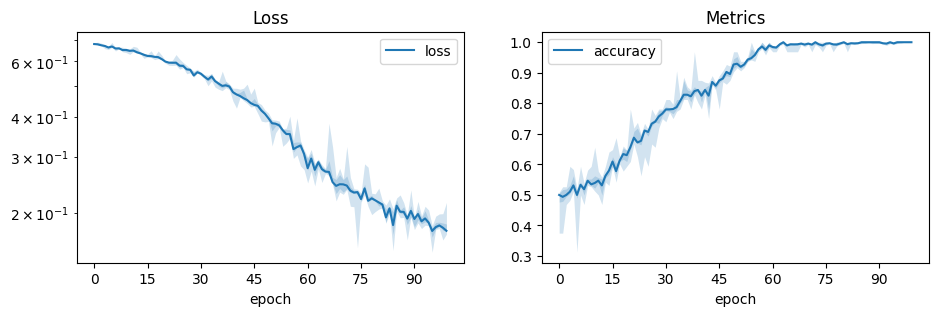

In [90]:
tinstr.plot_train_history(history)

And the overview plot:

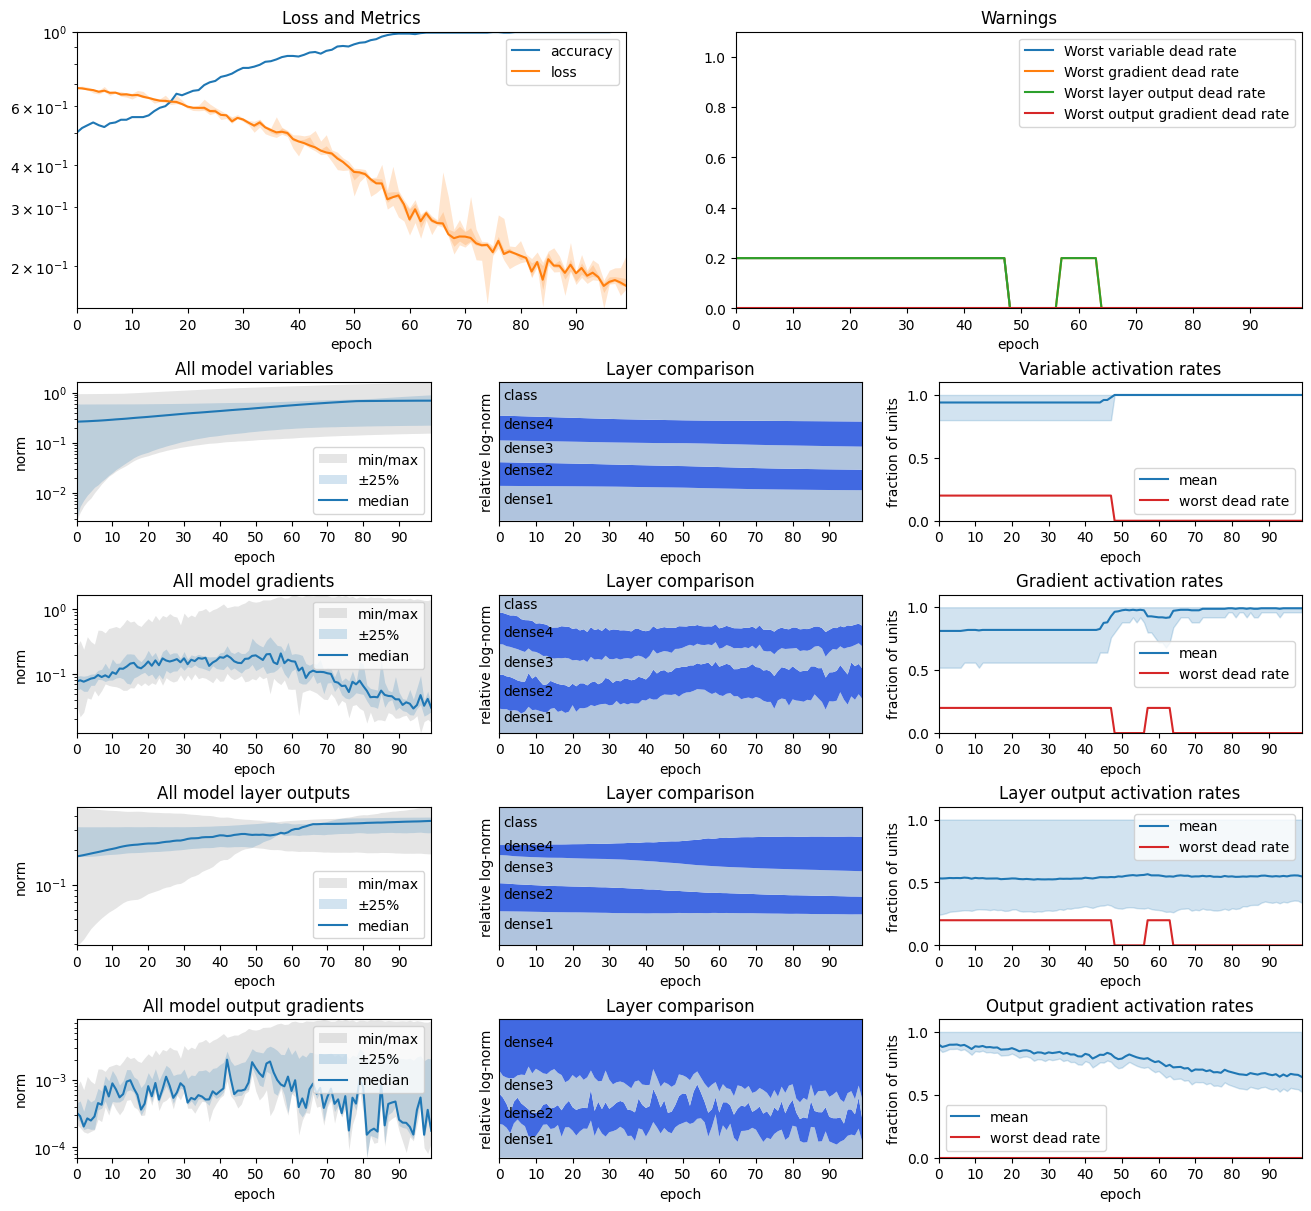

In [91]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

**Commentary**

If you look closely, it's already clear that the ReLU activation function leads to very different behaviour. Training progresses quickly towards 100% accuracy. There is a very different "layer comparison" being revealed.

But let's use our new plotting function to see that directly...

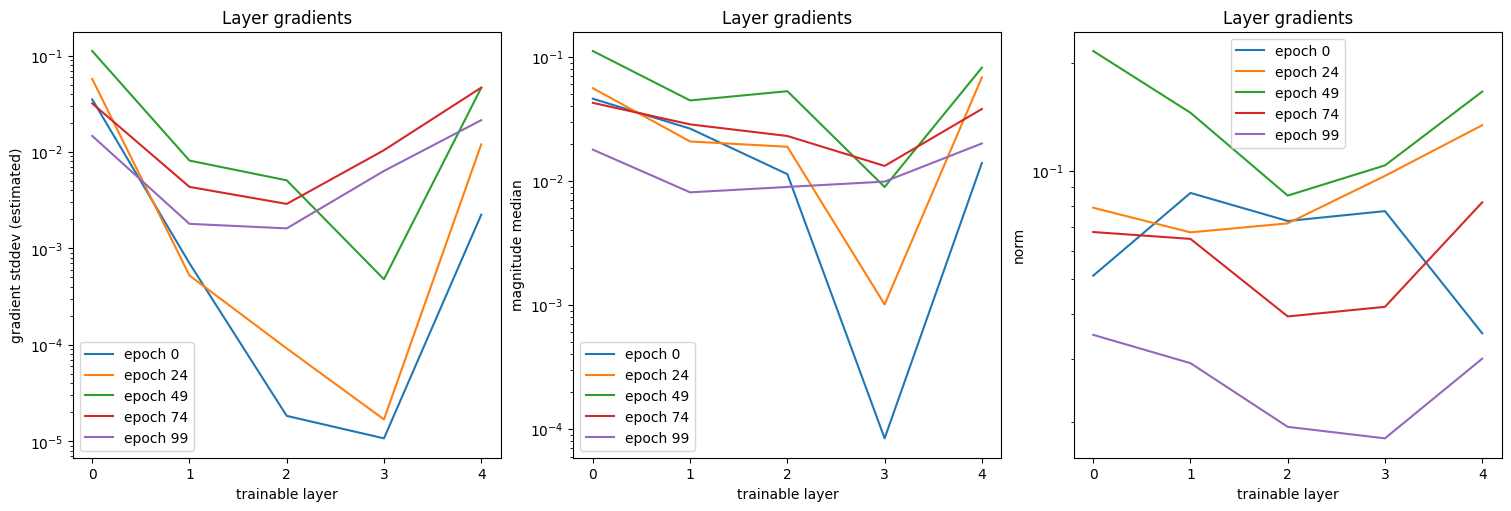

In [92]:
plot_layer_magnitudes(gradients)

**Commentary**

For this small 5-layer network, the gradients flow more-or-less equally between the layers.

You'll notice that there's still quite a lot of variation from layer to layer. The exact pattern that you'd expect will vary depending on the architecture. For example, it's also quite common for the model to be very wide in the middle and for its first and last layers to be narrow. This tends to be associated with a "U" shaped plot across the layers - with the earliest and latest layers have higher gradient magnitudes than the inner layers.

One important measure is that the magnitudes of the first layer's gradients are about equal (or even greater) than the last layer. Another important measure is that all of the hidden layers have at least _some_ gradient.

## Larger Networks

To further extend our comparison. Let's run the same for a deeper ReLU network.

In [93]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = binary_classification_model('relu', 'he_normal', hidden_layers=10)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = tinstr.fit(model, train_X, train_Y, batch_size=32, epochs=100, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), tinstr.HistoryStats(), variables, gradients, outputs, output_gradients])

Epoch    10 - 2.34s/epoch: accuracy: 0.7500  loss: 0.6863  
Epoch    20 - 294.78ms/epoch: accuracy: 0.8300  loss: 0.6007  
Epoch    30 - 361.84ms/epoch: accuracy: 0.8533  loss: 0.3775  
Epoch    40 - 305.32ms/epoch: accuracy: 0.8767  loss: 0.3115  
Epoch    50 - 293.03ms/epoch: accuracy: 0.8833  loss: 0.2789  
Epoch    60 - 284.48ms/epoch: accuracy: 0.8967  loss: 0.2452  
Epoch    70 - 394.28ms/epoch: accuracy: 0.9200  loss: 0.1989  
Epoch    80 - 283.14ms/epoch: accuracy: 0.9367  loss: 0.1539  
Epoch    90 - 282.93ms/epoch: accuracy: 0.9933  loss: 0.0685  
Epoch   100 - 292.63ms/epoch: accuracy: 1.0000  loss: 0.0152  


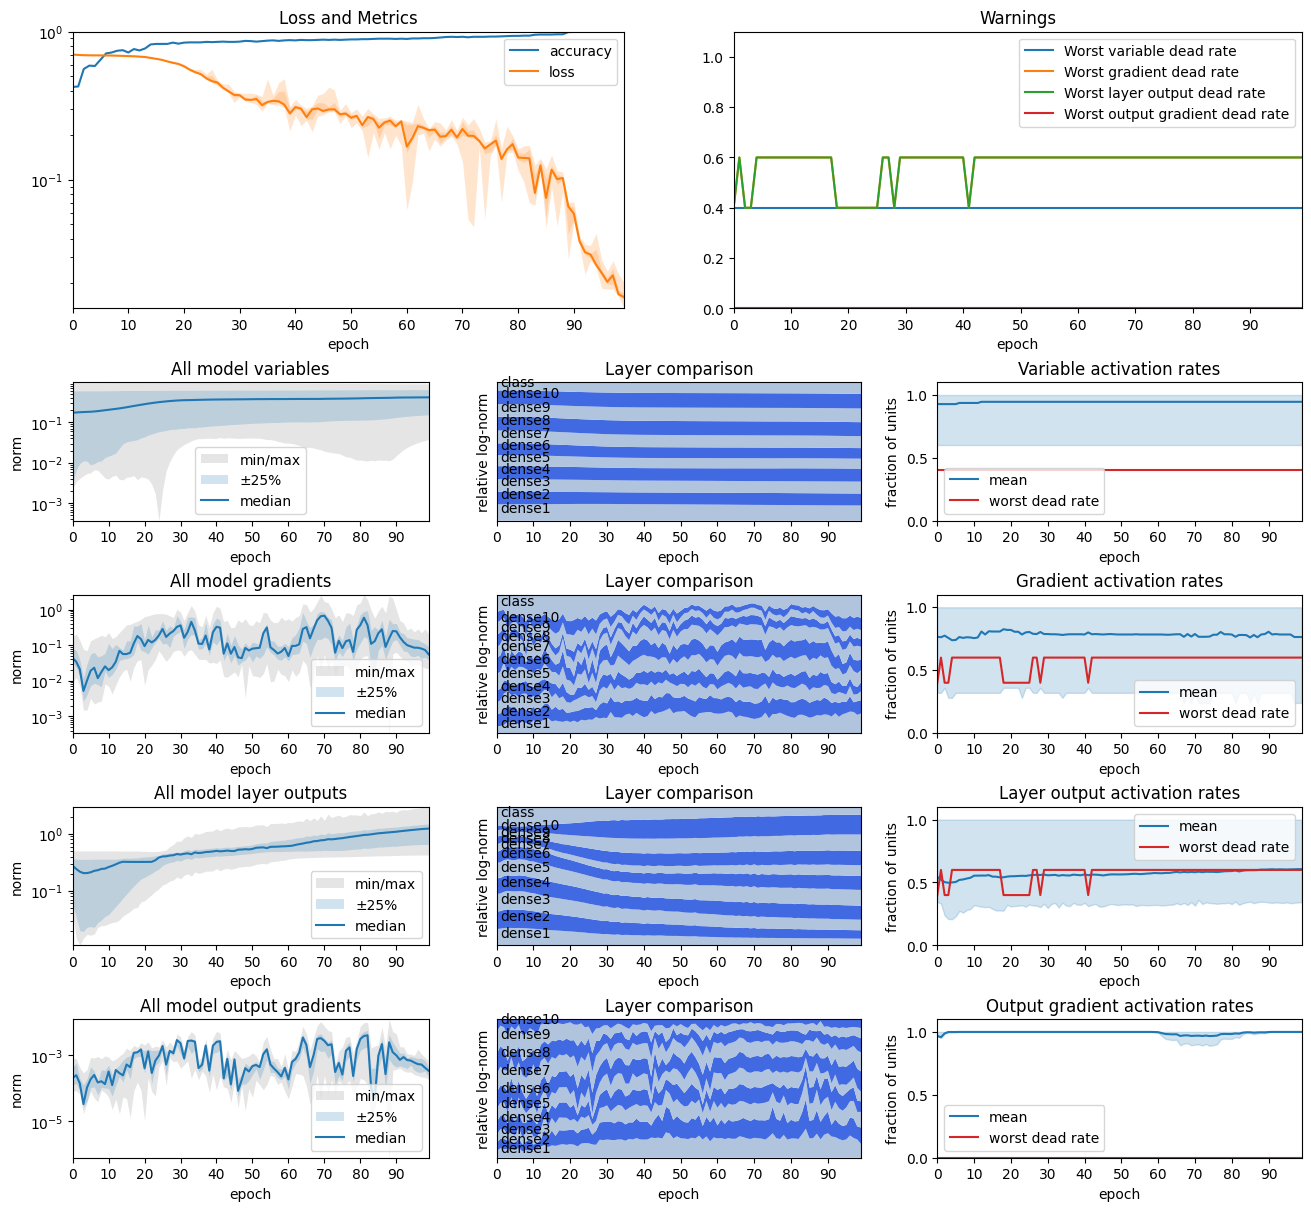

In [94]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

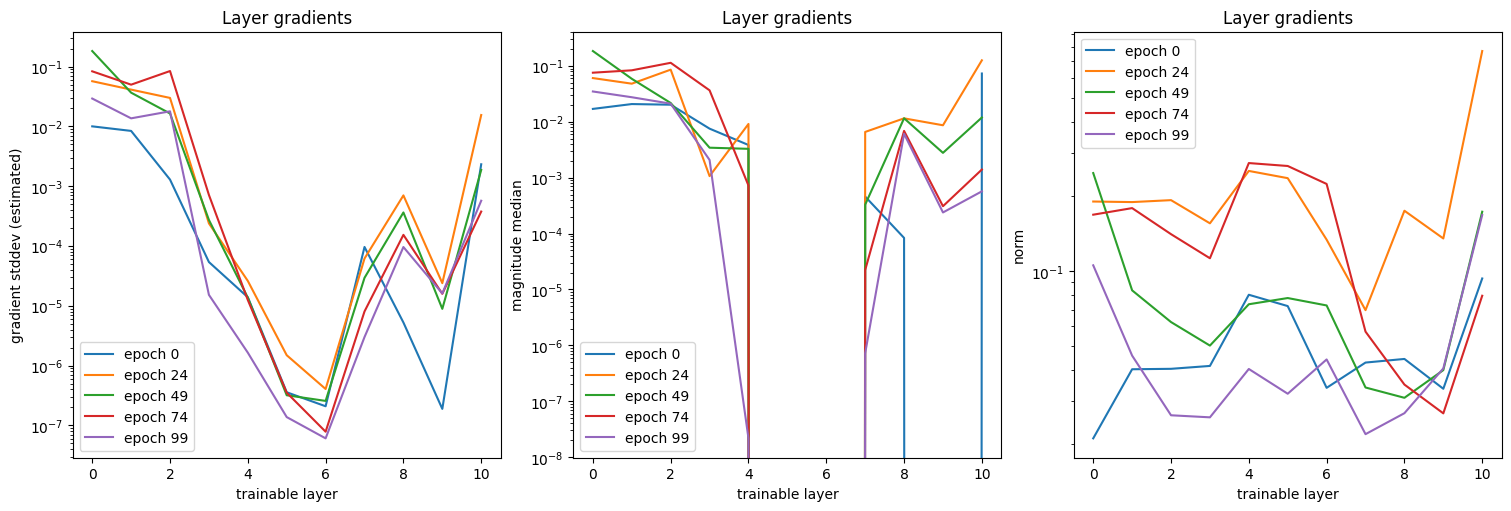

In [95]:
plot_layer_magnitudes(gradients)

**Commentary**

There's two different things going on here.

Firstly, the good news. Even for this larger network, the gradient magnitudes are more-or-less uniform from the first layer to the last. The model also trains very fast and reaches 100% train-set accuracy.

Secondly, the bad news. What's going on with the middle layers in the magnitude median plot?

Let's take a closer look at the full distribution of gradients across each layer...



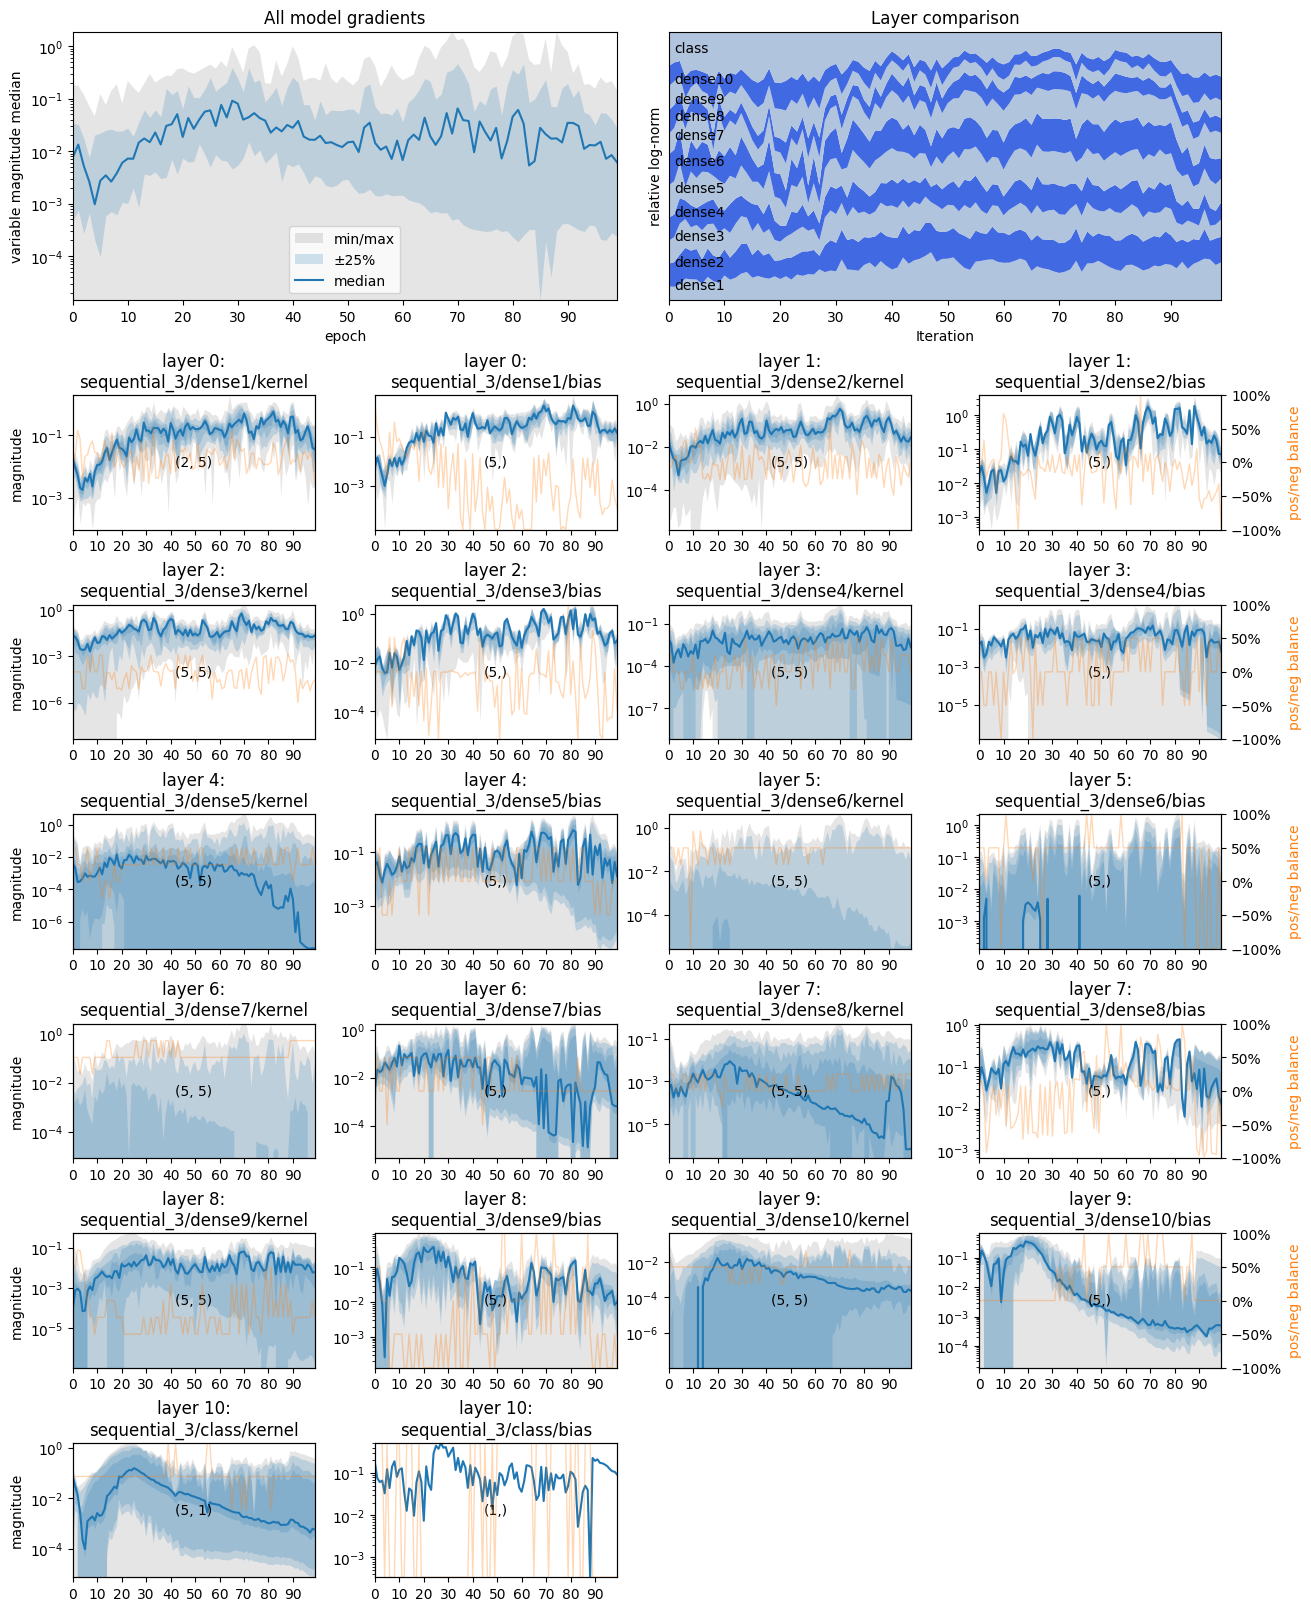

In [96]:
tinstr.plot_value_history(gradients)

**Commentary**

Notice that for some layers the solid blue line disappears - that's the magnitude median. The plots are telling us that many of the gradients are zero.

To see that more clearly, we can use what I call an "activity plot". It examines the percentages of "active" (non-zero) values present with the gradient tensors. It also examines the percentage of "dead" units - individual units that have zero gradients for all data samples.

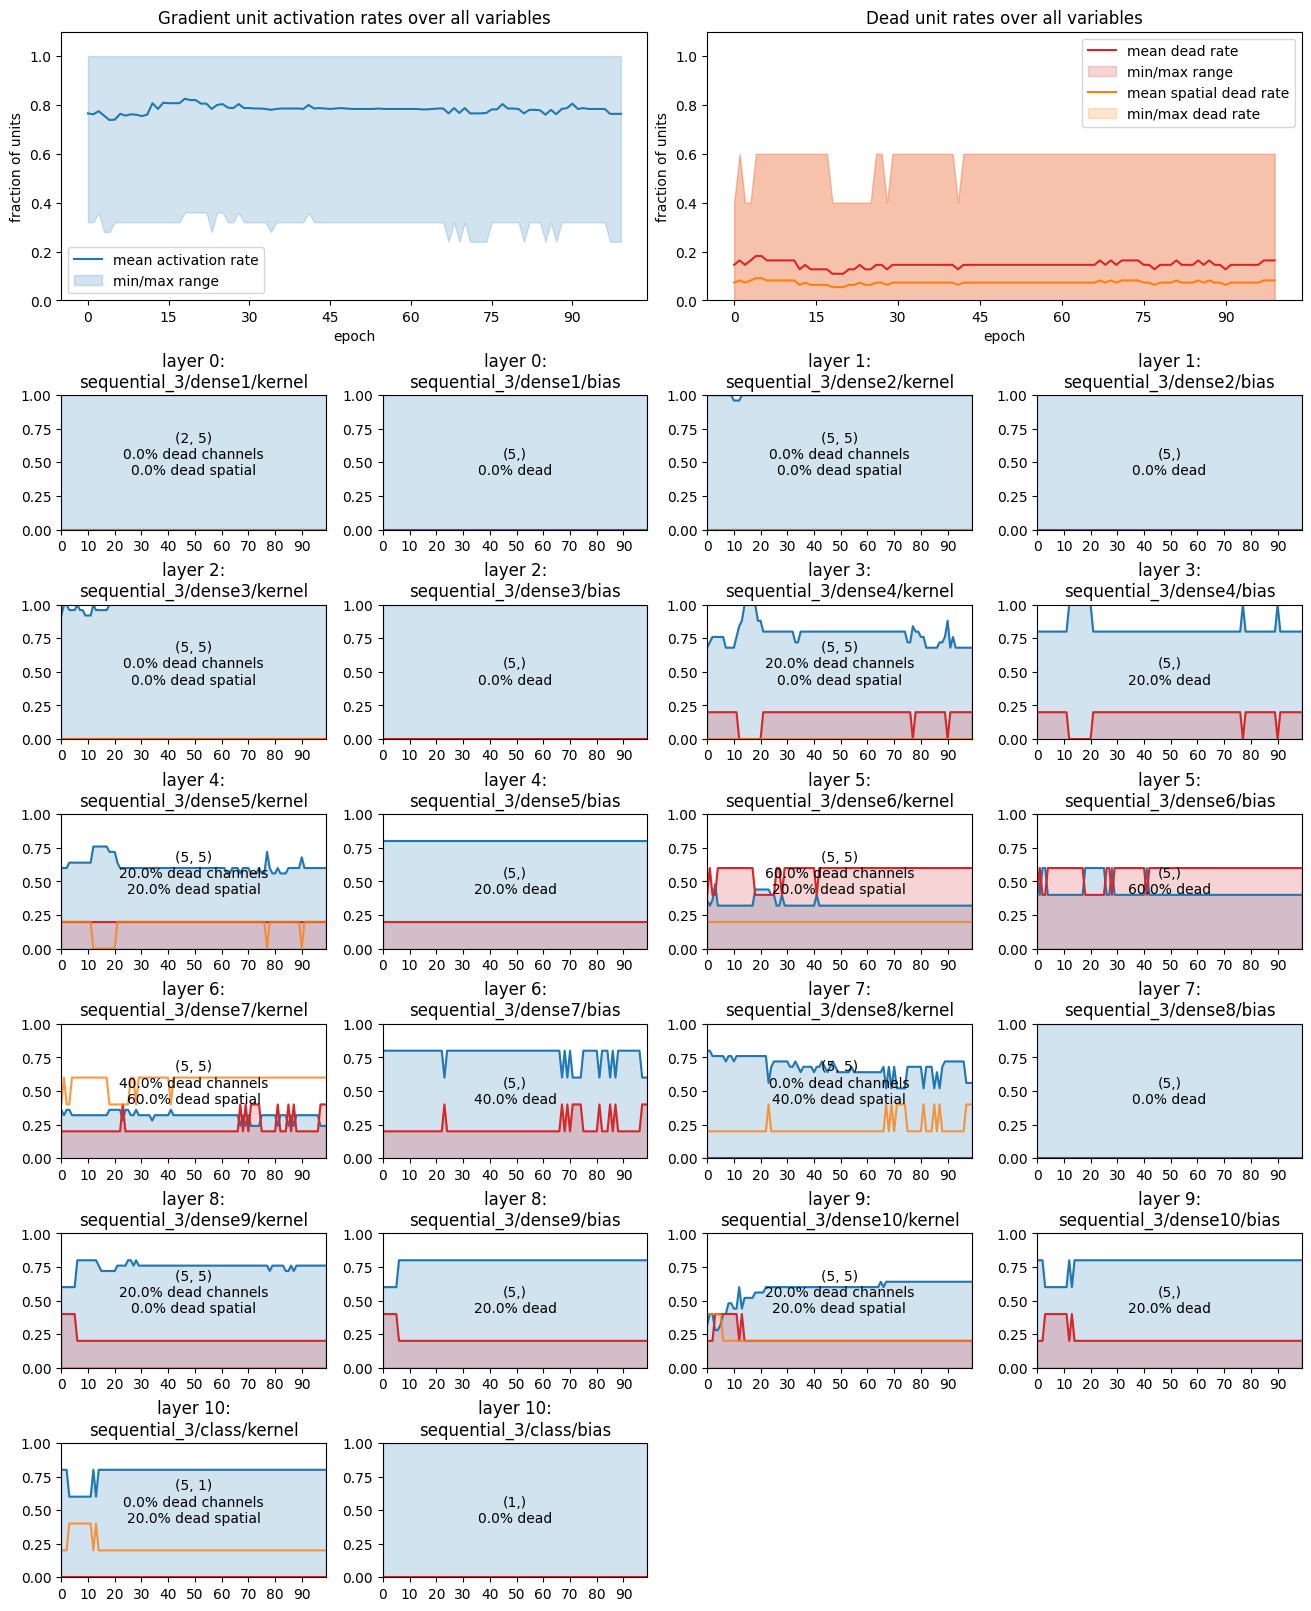

In [97]:
tinstr.plot_activity_history(gradients)

**Commentary**

Notice that about half of layers suffer from high neuron death.

Neuron death can be very bad and can cause networks to fail to train. However our network trains very efficiently and quickly reaches 100% accuracy. Our network is simply over-provisioned for the problem. It contains many redudant weights, and the training algorithm is pruning them - probably by setting their outputs to zero.

For a more detailed analysis of network death, see the `neuron-death.ipynb` notebook in the same folder as this.

## Tanh Activation Function

Another popular activation function is the hyperbolic tangent, or Tanh. It is sometimes used as a smooth equivalent of ReLU because it has a similar shape.

Let's see how it compares for vanishing gradients on the smaller network.



In [98]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = binary_classification_model('tanh', 'glorot_uniform', num_hidden_layers=4)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = tinstr.fit(model, train_X, train_Y, batch_size=32, epochs=100, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), tinstr.HistoryStats(), variables, gradients, outputs, output_gradients])

Epoch    10 - 1.27s/epoch: accuracy: 0.5633  loss: 0.6917  
Epoch    20 - 254.02ms/epoch: accuracy: 0.6867  loss: 0.6870  
Epoch    30 - 290.82ms/epoch: accuracy: 0.6167  loss: 0.6708  
Epoch    40 - 309.10ms/epoch: accuracy: 0.6533  loss: 0.6267  
Epoch    50 - 271.68ms/epoch: accuracy: 0.8300  loss: 0.5342  
Epoch    60 - 265.56ms/epoch: accuracy: 0.9433  loss: 0.3822  
Epoch    70 - 267.30ms/epoch: accuracy: 1.0000  loss: 0.2224  
Epoch    80 - 258.72ms/epoch: accuracy: 1.0000  loss: 0.1223  
Epoch    90 - 283.77ms/epoch: accuracy: 1.0000  loss: 0.0718  
Epoch   100 - 277.77ms/epoch: accuracy: 1.0000  loss: 0.0455  


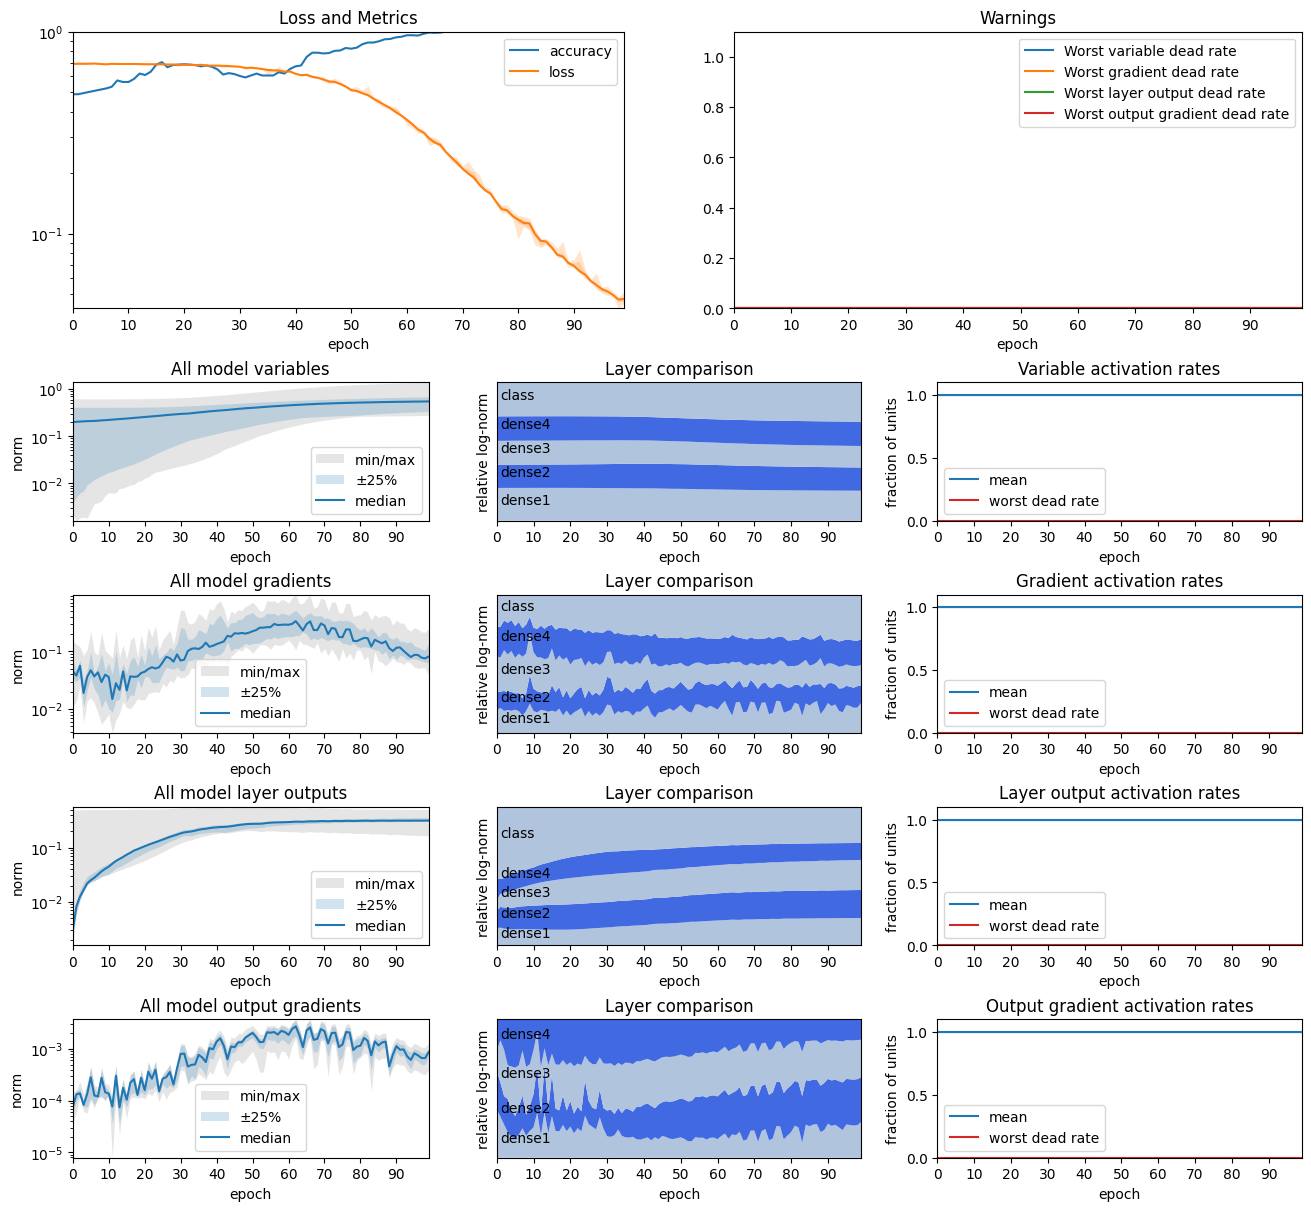

In [99]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

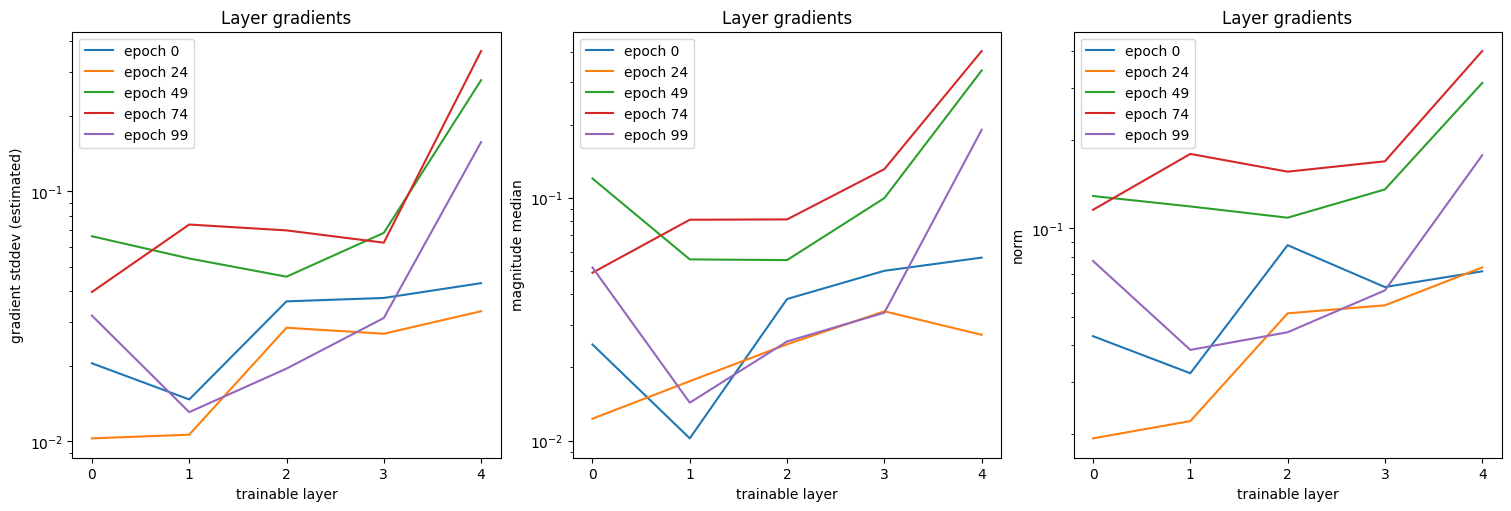

In [100]:
plot_layer_magnitudes(gradients)

**Commentary**

Tanh doesn't suffer from such an obvious vanishing gradient problem as sigmoid, but it can suffer a little.

If you're running the notebook yourself, you find quite a variation of results above. I've found that sometimes the earliest layers have smaller gradients by about an order of magnitude, whereas other times they're compariable or even larger than the last layers. Additionally, sometimes the model trains well within this short 100 epoch run, while other times it does badly.

## Typical U-shaped Layer Gradients
I mentioned earlier that it's quite common for the gradient magnitudes across layers to follow a "U"-shape.

Before leaving the topic of vanishing gradients, I wanted to illustrate that. Below is a simple image classification problem using a CNN model.

_Tip: best run with a GPU. Below trains in 1 to 2 min on a T4 GPU._

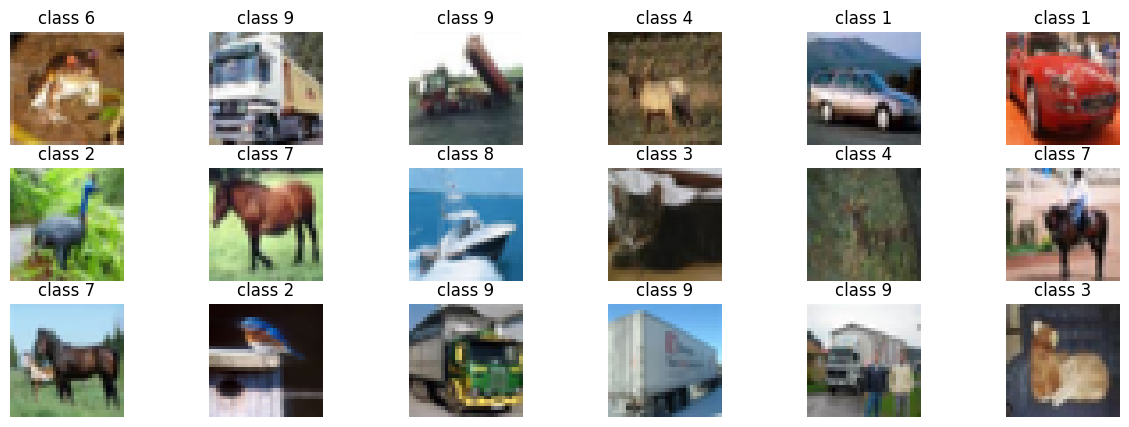

In [101]:
# Load CIFAR-10 dataset
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0

# Plot some examples
plt.figure(figsize=(15,5))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    plt.title(f"class {y_train[i][0]}")
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()

In [102]:
def classification_model():
    image_input = tf.keras.Input(shape=(32, 32, 3), name="image_input")

    # convolutional layers
    # - 32x32x3 -> 16x16x8 -> 8x8x16 -> 4x4x32 -> 2x2x64
    conv = layers.Conv2D(filters=8, kernel_size=3, activation='relu', padding='same', name='conv2d_1a')(image_input)
    conv = layers.Conv2D(filters=8, kernel_size=3, activation='relu', padding='same', name='conv2d_1b')(conv)
    conv = layers.MaxPooling2D(pool_size=2, name='pool2d_1')(conv)
    conv = layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', name='conv2d_2a')(conv)
    conv = layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', name='conv2d_2b')(conv)
    conv = layers.MaxPooling2D(pool_size=2, name='pool2d_2')(conv)
    conv = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='conv2d_3a')(conv)
    conv = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='conv2d_3b')(conv)
    conv = layers.MaxPooling2D(pool_size=2, name='pool2d_3')(conv)
    conv = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='conv2d_4a')(conv)
    conv = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='conv2d_4b')(conv)
    conv = layers.MaxPooling2D(pool_size=2, name='pool2d_4')(conv)

    # dense layers
    # - 2x2x64 -> 256 -> 128 -> 10
    out = layers.Flatten(name='x1_flatten')(conv)
    out = layers.Dense(128, activation='relu', name='x1_dense_1')(out)
    out = layers.Dense(128, activation='relu', name='head_dense1')(out)
    out = layers.Dense(128, activation='relu', name='head_dense2')(out)
    out = layers.Dense(10, activation='linear', name='head_dense3')(out)  # logits output

    return tf.keras.Model(inputs=image_input, outputs=out)

# Uncomment to print model summary
#classification_model().summary()

In [103]:
variables = tinstr.VariableHistoryCallback(activity_stats=False)
gradients = tinstr.GradientHistoryCallback(activity_stats=False)
outputs = tinstr.LayerOutputHistoryCallback(activity_stats=False)
output_gradients = tinstr.LayerOutputGradientHistoryCallback(activity_stats=False)

model = classification_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))
dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).take(6000).batch(32)
history = tinstr.fit(model, dataset, epochs=50, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

Epoch     5 - 5.23s/epoch: loss: 1.6328  
Epoch    10 - 3.84s/epoch: loss: 1.2791  
Epoch    15 - 2.96s/epoch: loss: 0.9706  
Epoch    20 - 3.26s/epoch: loss: 0.6867  
Epoch    25 - 3.35s/epoch: loss: 0.4982  
Epoch    30 - 3.59s/epoch: loss: 0.3534  
Epoch    35 - 3.50s/epoch: loss: 0.2370  
Epoch    40 - 2.90s/epoch: loss: 0.1793  
Epoch    45 - 3.23s/epoch: loss: 0.1616  
Epoch    50 - 2.73s/epoch: loss: 0.1404  


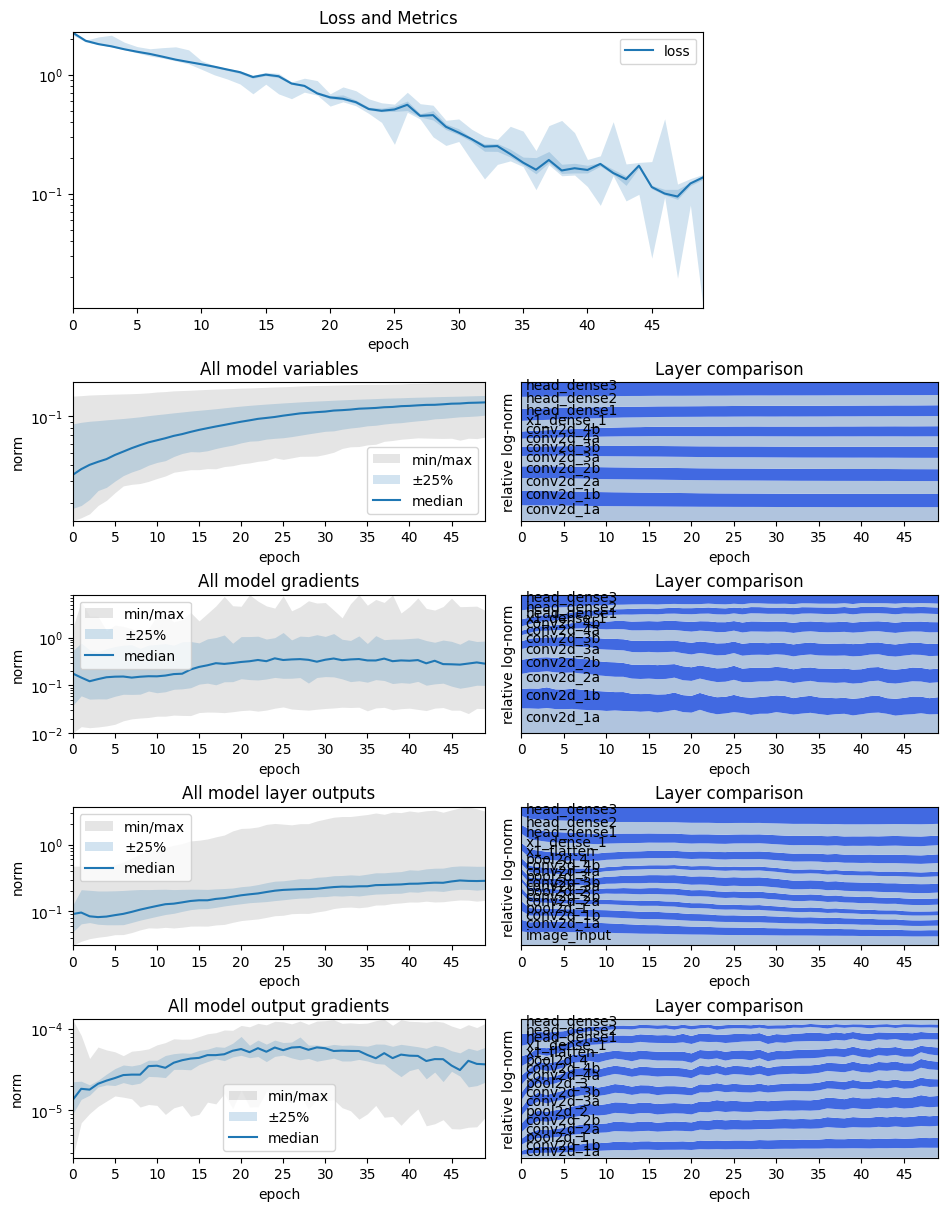

In [104]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

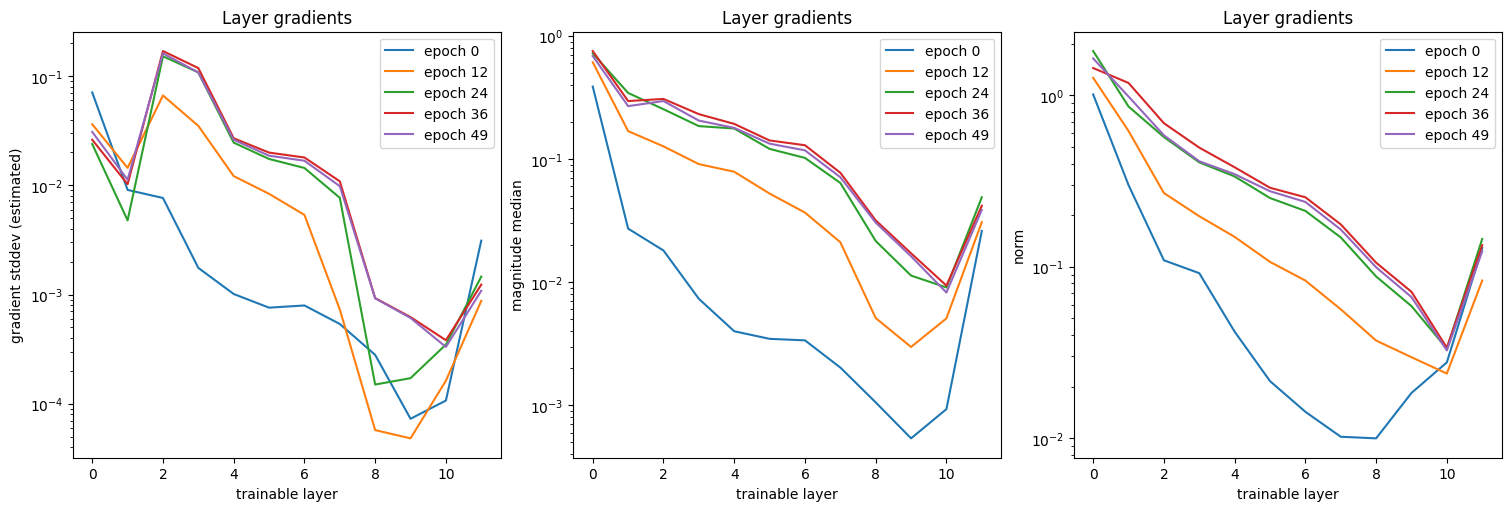

In [105]:
plot_layer_magnitudes(gradients)

**Commentary**

Well, we didn't manage to replicate the beautiful "U"-shaped plot that I've seen in some blogs, but there is a definite pattern whereby some of the middle layers have smaller gradients than both the first and last layers. Also notice the continued trend that the first layer has a _higher_ gradient than the last layer.

And which version of the plot should you use? Clearly they all show similar trends, so it doesn't matter too much. The biggest factor will be how you impact training performance. If you use the toolkit callbacks out of the box, they slow down training, particularly due to computing the percentile distributions. If you were writing your own callback just to collect information needed for these plots, I'd probably go with either stddev or size-normalized norm.

_Tip: if you do come to implement this for yourself on TensorFlow, just calculate the RMS value. It's mathematically equivalent to a size-normalized norm, but it's about twice as fast to calculate._

## Exploding Gradients

Finally, we can use the same plotting technique to observe exploding gradients.This section illustrates the problem of exploding gradient due to insufficient normalization.

Neural networks work best when their values are approximately within the range -1.0 .. 1.0. This means that each layer computes its gradients with matrix multiplications between tensors of numbers on the order of 1.0. Each layer adds an additional iteration of such a multiplication. The net result is that the network ends up working with numbers that on the range of that base scale taken to the power of the number of layers:

$$1.0 ^ L$$

That's fine if the base scale is around 1.0. But it leads to exploding gradients if the base scale is larger, eg:

$$10.0 ^ L$$

The following attempts to train a network for a regression task where the output values are in the range -600 to +600. It does this without any normalization, forcing the network weights to produce such values. This leads to exploding gradients for the reasons mentioned.

In [168]:
x_train, y_train = sklearn.datasets.make_regression(n_samples=1000, n_features=20, noise=0.1, random_state=35)
print(f"x_train shape: {x_train.shape} in range {np.min(x_train)} .. {np.max(x_train)}")
print(f"y_train shape: {y_train.shape} in range {np.min(y_train)} .. {np.max(y_train)}")

x_train shape: (1000, 20) in range -3.7779320999216757 .. 3.8207562252553675
y_train shape: (1000,) in range -672.5331422261322 .. 580.1158144715589


In [169]:
def exploding_model():
  return tf.keras.Sequential([
      layers.Input((20,), name="input"),
      layers.Dense(25, activation='relu', kernel_initializer='he_normal', name="dense1"),
      layers.Dense(25, activation='relu', kernel_initializer='he_normal', name="dense2"),
      layers.Dense(25, activation='relu', kernel_initializer='he_normal', name="dense3"),
      layers.Dense(1, name="out"),
  ])

In [170]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

tf.keras.utils.set_random_seed(1)
tf.config.experimental.enable_op_determinism()

model = exploding_model()
model.compile(optimizer='adam', loss='mse')
history = tinstr.fit(model, x_train, y_train, batch_size=32, epochs=10, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), tinstr.HistoryStats(), variables, gradients, outputs, output_gradients])

Epoch     1 - 1.96s/epoch: loss: 38105.2266  
Epoch     2 - 5.03s/epoch: loss: 37894.0312  
Epoch     3 - 481.14ms/epoch: loss: 37494.5430  
Epoch     4 - 367.46ms/epoch: loss: 36525.8086  
Epoch     5 - 618.94ms/epoch: loss: 34054.2656  
Epoch     6 - 607.70ms/epoch: loss: 28472.1230  
Epoch     7 - 617.53ms/epoch: loss: 18959.6367  
Epoch     8 - 628.88ms/epoch: loss: 8495.2412  
Epoch     9 - 621.38ms/epoch: loss: 2805.1799  
Epoch    10 - 618.97ms/epoch: loss: 1429.6334  


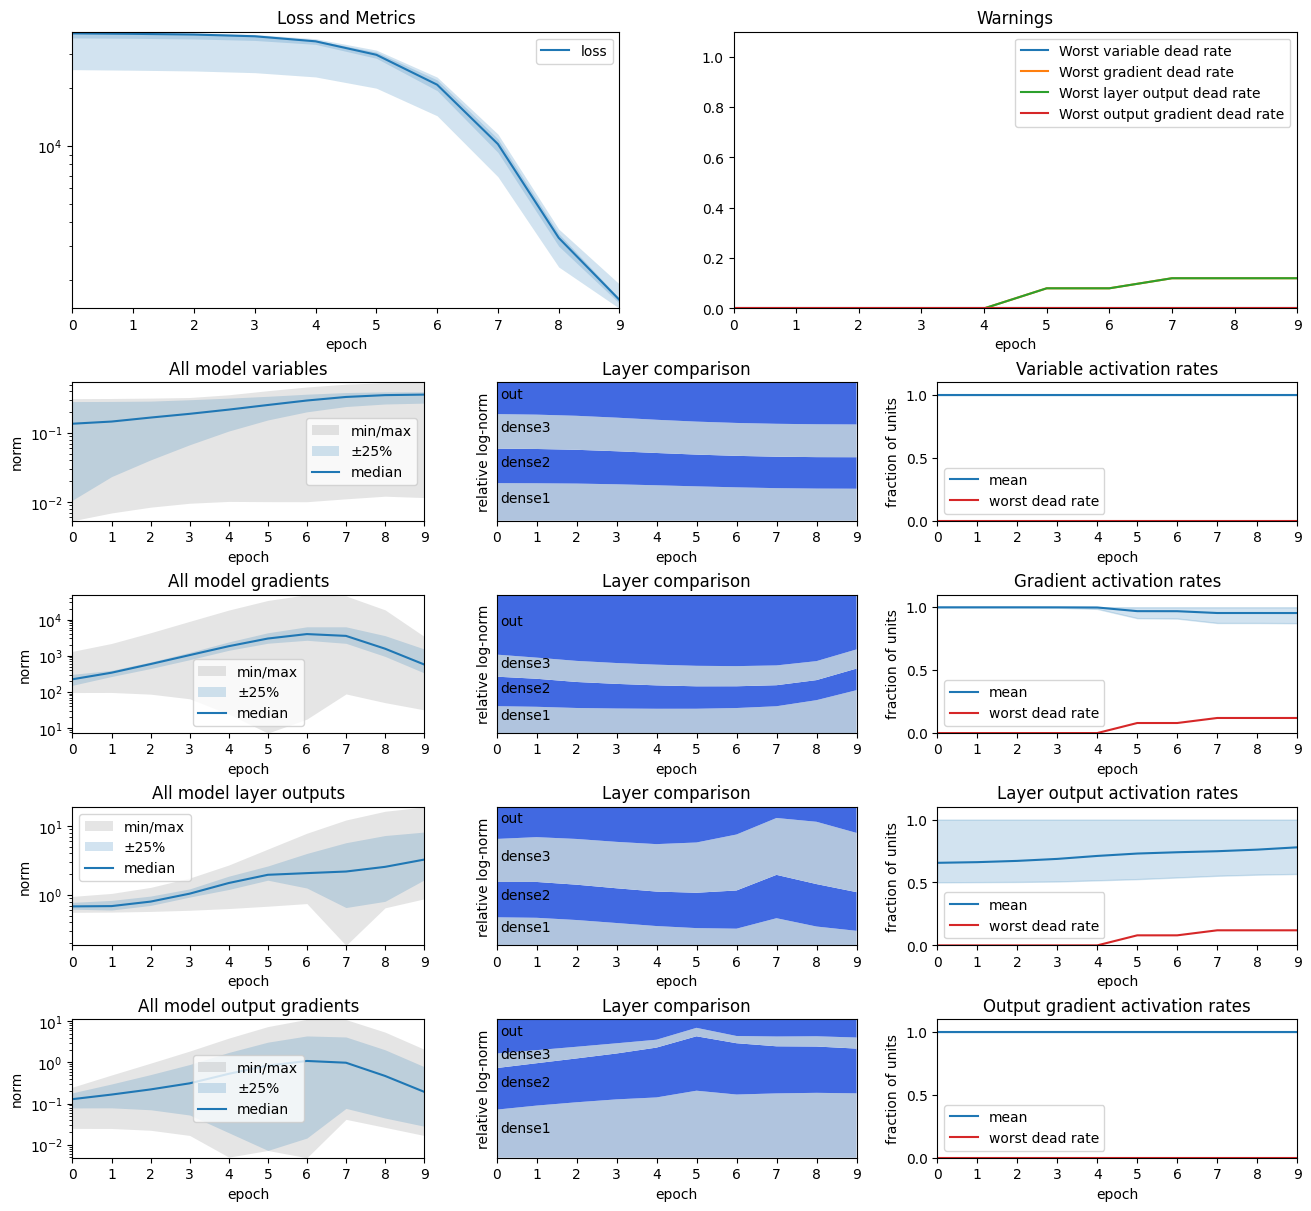

In [171]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

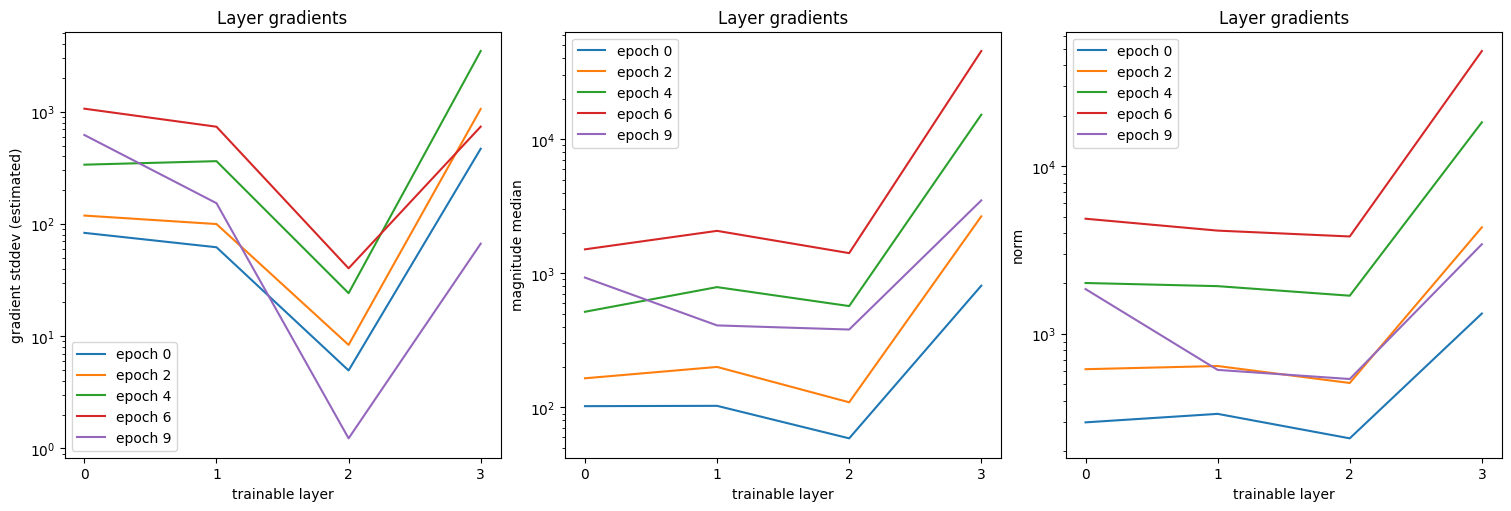

In [172]:
plot_layer_magnitudes(gradients)

**Commentary**

Notice that our new favourite layer magnitudes plot doesn't quite do justice to the problem....until you look at the scale!

Those are gradient magnitudes on the order of 100 to 1000.

We're used to seeing gradient magnitudes well below 1.0.

By the way, the Adam optimizer does a very good job of coping with a very wide range of bad situations. If you tried to train the above with basic SGD, you'd just get NaN losses throughout. Also note that the model has more layers than are needed for a simple regression task. I added a few extra layers so that you can more easily see the problem across multiple layers. You could use a single relu layer instead and still get the same result.

**Explicit Scaling**

You can easily fix the problem in this current case by changing nothing but explicitly scaling the y labels to within -1 .. +1.

In [178]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

tf.keras.utils.set_random_seed(1)
tf.config.experimental.enable_op_determinism()

y_scaled = y_train / 600.0

model = exploding_model()
model.compile(optimizer='adam', loss='mse')
history = tinstr.fit(model, x_train, y_scaled, batch_size=32, epochs=10, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), tinstr.HistoryStats(), variables, gradients, outputs, output_gradients])

Epoch     1 - 2.05s/epoch: loss: 0.6009  


Epoch     2 - 8.73s/epoch: loss: 0.2334  
Epoch     3 - 497.52ms/epoch: loss: 0.1540  
Epoch     4 - 648.31ms/epoch: loss: 0.1176  
Epoch     5 - 639.02ms/epoch: loss: 0.0951  
Epoch     6 - 477.79ms/epoch: loss: 0.0796  
Epoch     7 - 628.52ms/epoch: loss: 0.0680  
Epoch     8 - 350.91ms/epoch: loss: 0.0593  
Epoch     9 - 626.82ms/epoch: loss: 0.0525  
Epoch    10 - 611.26ms/epoch: loss: 0.0469  


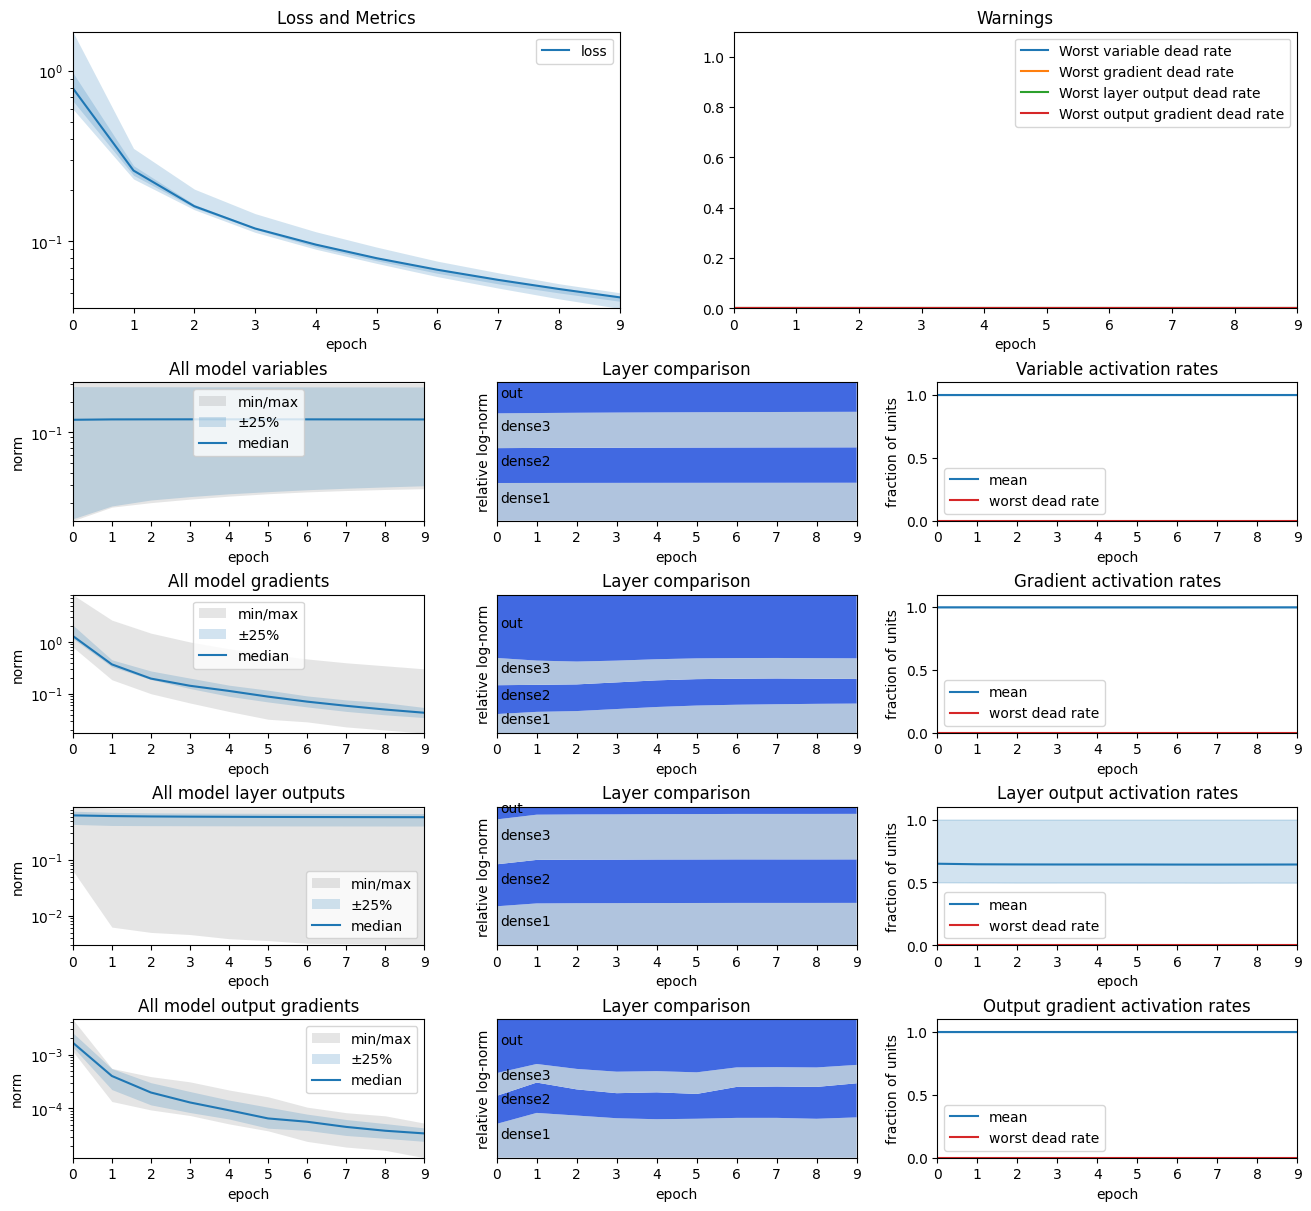

In [179]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

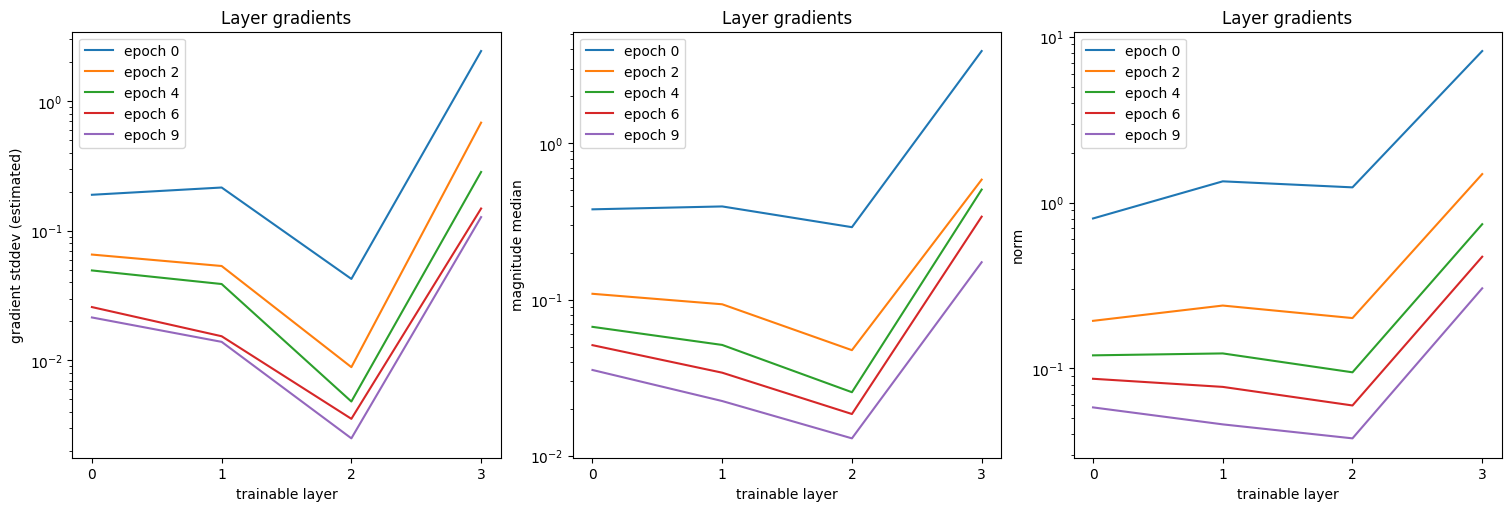

In [180]:
plot_layer_magnitudes(gradients)

**Auto-normalization**

The automatic equivalent is to learn the normalization required by doing something like the following and then using one of the sklearn tools to normalize the y_true values.

```python
def normalized_model(input_normalizer):
  return tf.keras.Sequential([
      layers.Input((20,), name="input"),
      input_normalizer,
      layers.Dense(25, activation='relu', kernel_initializer='he_normal', name="dense1"),
      layers.Dense(25, activation='relu', kernel_initializer='he_normal', name="dense2"),
      layers.Dense(25, activation='relu', kernel_initializer='he_normal', name="dense3"),
      layers.LayerNormalization(name="batchnorm"),
      layers.Dense(1, name="out")
  ])

input_normalizer = layers.Normalization(axis=-1)
input_normalizer.adapt(x_train)

model = normalized_model(input_normalizer)

```

**Normalization layers**

Another approach is to add normalization, but in our problem it might not work.
To illustrate, here's an updated model with batch-norm added in a few places.

In [192]:
def normalized_model():
  return tf.keras.Sequential([
      layers.Input((20,), name="input"),
      layers.BatchNormalization(name="batchnorm1"),
      layers.Dense(25, activation='relu', kernel_initializer='he_normal', name="dense1"),
      layers.Dense(25, activation='relu', kernel_initializer='he_normal', name="dense2"),
      layers.Dense(25, activation='relu', kernel_initializer='he_normal', name="dense3"),
      layers.BatchNormalization(name="batchnorm2"),
      layers.Dense(1, name="out"),
      layers.BatchNormalization(name="batchnorm3"),
  ])

In [193]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

tf.keras.utils.set_random_seed(1)
tf.config.experimental.enable_op_determinism()

model = normalized_model()
model.compile(optimizer='adam', loss='mse')
history = tinstr.fit(model, x_train, y_train, batch_size=32, epochs=10, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), tinstr.HistoryStats(), variables, gradients, outputs, output_gradients])

Epoch     1 - 3.42s/epoch: loss: 38118.2578  
Epoch     2 - 5.93s/epoch: loss: 37993.4648  
Epoch     3 - 484.35ms/epoch: loss: 37896.5273  
Epoch     4 - 593.49ms/epoch: loss: 37830.4883  
Epoch     5 - 663.43ms/epoch: loss: 37790.0547  
Epoch     6 - 588.02ms/epoch: loss: 37760.1992  
Epoch     7 - 620.10ms/epoch: loss: 37735.9805  
Epoch     8 - 630.65ms/epoch: loss: 37714.6445  
Epoch     9 - 627.89ms/epoch: loss: 37695.5117  
Epoch    10 - 475.13ms/epoch: loss: 37677.7812  


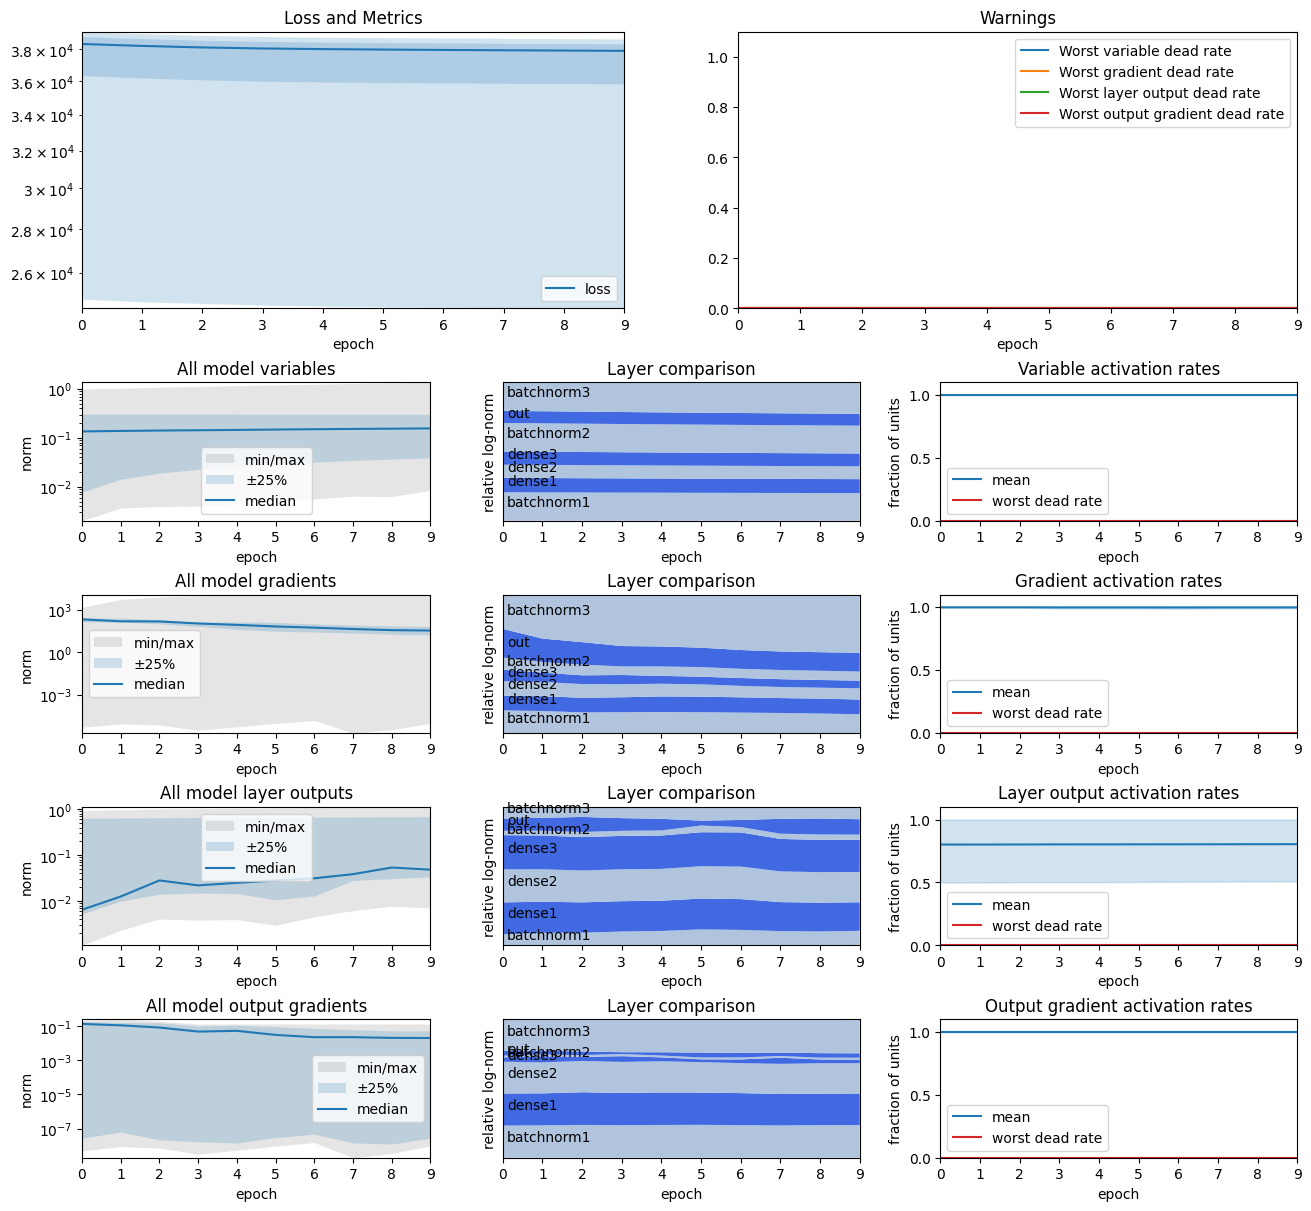

In [194]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

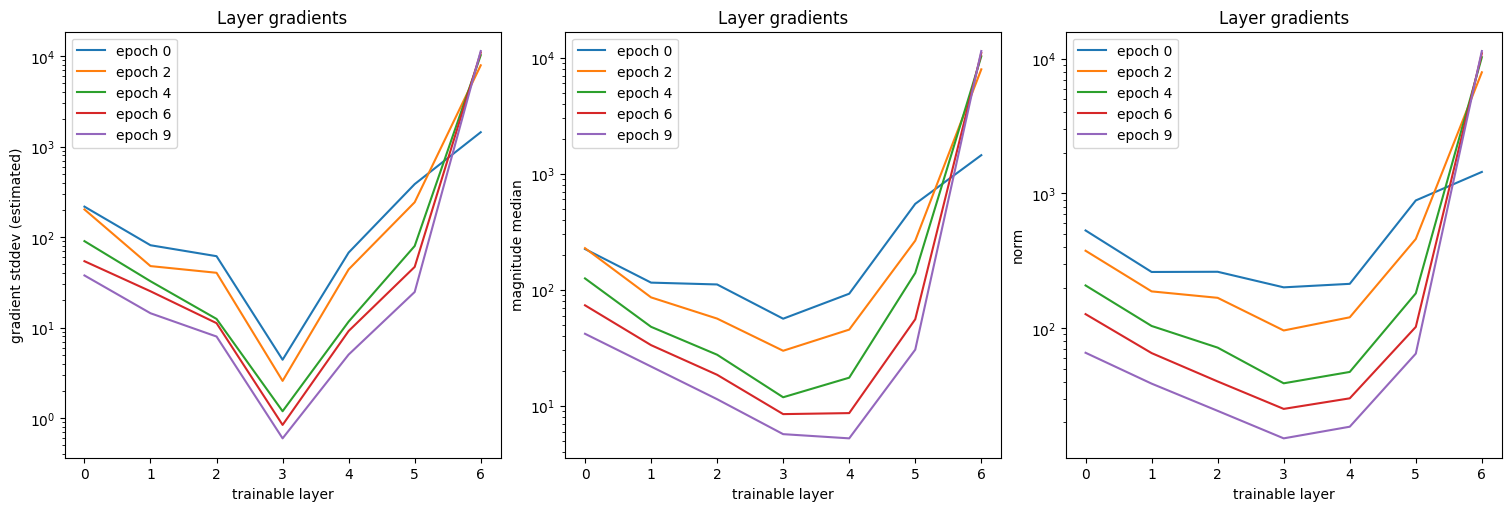

In [195]:
plot_layer_magnitudes(gradients)

**Commentary**

Batch-norm appears to improve the situation from the point of view of the gradient magnitudes. But training is still very slow. It would like converge to a good result eventually, but only after many more epochs than needed if you've already pre-scaled the values.

We'd also get the same results with Layer-norm.

But that's just for this particular model and dataset. There's no one simple rule. You have to experiment. But what you really need are the tools to see clearly the results of your experiments.

I hope you find the toolkit helpful to that end.

## References

The following papers introduced the initialization schemes that were used here (listed in reverse chronological order):

* He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification. ArXiv. https://arxiv.org/abs/1502.01852

* Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. PMLR 9:256-256. https://proceedings.mlr.press/v9/glorot10a.html
